## 0. Types de Données et Fonctions Utilitaires

### 0.1 Introduction aux Types de Données

On considère un ensemble de candidats/objets évalués selon plusieurs critères. Chaque candidat $c$ a une valuation $v_c(i)$ pour chaque critère $i$.

**Notation:**
- Comparaison $x \succ y$ : l'objet $x$ est préféré à $y$
- Différence: $\text{diff}(x, y)[i] = v_x(i) - v_y(i)$ pour le critère $i$
- **Pros**: critères où $x$ est supérieur à $y$ (différence positive)
- **Cons**: critères où $x$ est inférieur à $y$ (différence négative)

### 0.2 Imports et Configuration

In [219]:
!pip install networkx

In [220]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import numpy as np
from typing import Tuple, List, Union, Dict

### 0.3 Fonctions Utilitaires

In [221]:
def def_pros_cons_neutrals(differences: Dict[str, float]) -> Tuple[List[str], List[str], List[str]]:
    """
    Identifie les critères positifs (pros), négatifs (cons) et neutres.
    
    Args:
        differences: Dict[str, float] - différences de valuation pour chaque critère
    
    Returns:
        Tuple[List, List, List] - (pros, cons, neutrals)
    """
    pros = []
    cons = []
    neutrals = []
    
    for critere, valeur in differences.items():
        if valeur > 0:
            pros.append(critere)
        elif valeur < 0:
            cons.append(critere)
        else:
            neutrals.append(critere)
    
    return pros, cons, neutrals


def def_trade_offs(differences: Dict[str, float]) -> List[List[str]]:
    """
    Calcule tous les trade-offs possibles (paires pro-con avec somme positive).
    
    Un trade-off (i, j) est valide si: valuation[pro] + valuation[con] > 0
    
    Args:
        differences: Dict[str, float] - différences de valuation
    
    Returns:
        List[List[str, str]] - liste de paires [pro, con]
    """
    pros, cons, _ = def_pros_cons_neutrals(differences)
    trade_offs = []
    
    for pro in pros:
        for con in cons:
            if differences[pro] + differences[con] > 0:
                trade_offs.append([pro, con])
    
    return trade_offs


def compute_difference(candidat_x: Dict[str, float], candidat_y: Dict[str, float]) -> Dict[str, float]:
    """
    Calcule les différences de valuation entre deux candidats.
    
    Args:
        candidat_x: Dict[str, float] - valuations du candidat x
        candidat_y: Dict[str, float] - valuations du candidat y
    
    Returns:
        Dict[str, float] - différences x - y pour chaque critère
    """
    return {k: candidat_x[k] - candidat_y[k] for k in candidat_x.keys()}


print("Fonctions utilitaires chargées ✓")

Fonctions utilitaires chargées ✓


---
# Question 1: trade-offs (1-1) - Une Comparaison x ≻ y

## 1.1 Données d'Entrée

On considère deux candidats x et y évalués selon 7 critères (A, B, C, D, E, F, G).

In [222]:
# Données pour la Question 1
diff_q1 = {
    "A" : 32,
    "B" : 0,
    "C" : -28,
    "D" : 36,
    "E" : 48,
    "F" : -35,
    "G" : -42
}

# Afficher les données
df_q1 = pd.DataFrame(list(diff_q1.items()), columns=['Critère', 'Différence (x - y)'])
print("Question 1 - Données de différence (x - y):")
print(df_q1.to_string(index=False))

# Identifier pros et cons
pros_q1, cons_q1, neutrals_q1 = def_pros_cons_neutrals(diff_q1)
print(f"\nClassification:")
print(f"  Pros (différence positive):  {pros_q1}")
print(f"  Cons (différence négative):  {cons_q1}")
if neutrals_q1:
    print(f"  Neutres:                    {neutrals_q1}")

Question 1 - Données de différence (x - y):
Critère  Différence (x - y)
      A                  32
      B                   0
      C                 -28
      D                  36
      E                  48
      F                 -35
      G                 -42

Classification:
  Pros (différence positive):  ['A', 'D', 'E']
  Cons (différence négative):  ['C', 'F', 'G']
  Neutres:                    ['B']


## 1.2 Calcul des Trade-offs

Un **trade-off** est une paire (i,j) de type (pro, con) où la somme des contributions est positive:
$$\text{trade-off}(i, j) \text{ est valide si } diff[i] + diff[j] > 0$$

Cela signifie que l'avantage du pro compense (au moins partiellement) l'inconvénient du con.

In [223]:
# Calculer les trade-offs valides
trade_offs_q1 = def_trade_offs(diff_q1)

print(f"Trade-offs valides trouvés: {len(trade_offs_q1)}\n")
trade_offs_df_q1 = pd.DataFrame(
    [[pro, con, diff_q1[pro], diff_q1[con], 
      diff_q1[pro] + diff_q1[con]] 
     for pro, con in trade_offs_q1],
    columns=['Pro', 'Con', 'Diff(Pro)', 'Diff(Con)', 'Somme']
)
print(trade_offs_df_q1.to_string(index=False))

Trade-offs valides trouvés: 6

Pro Con  Diff(Pro)  Diff(Con)  Somme
  A   C         32        -28      4
  D   C         36        -28      8
  D   F         36        -35      1
  E   C         48        -28     20
  E   F         48        -35     13
  E   G         48        -42      6


## 1.3 Formulation du Programme Linéaire

### Théorie Mathématique

**Objectif:** Trouver une explication (1-1) de $x \succ y$, c'est-à-dire une bijection qui apparie chaque con de $y$ à un pro de $x$ compensateur.

**Variables de décision:**
$$z_{ij} \in \{0, 1\} \quad \text{pour chaque trade-off valide } (i, j)$$
où $z_{ij} = 1$ si le trade-off $(i, j)$ est sélectionné dans l'explication.

**Fonction objectif:**
$$\text{Maximiser} \sum_{(i,j)} z_{ij}$$

**Contraintes:**
1. **Couverture**: Chaque con doit être couvert exactement une fois
$$\sum_{i \text{ tel que } (i,j) \text{ valide}} z_{ij} = 1 \quad \forall j \in \text{Cons}$$

2. **Unicité**: Chaque pro peut être utilisé au plus une fois
$$\sum_{j \text{ tel que } (i,j) \text{ valide}} z_{ij} \leq 1 \quad \forall i \in \text{Pros}$$

## 1.4 Implémentation avec Gurobi

In [224]:
def exist_explication_1_1_avec_solveur(differences: Dict[str, float]) -> Tuple[bool, Union[List, str]]:
    """
    Formule et résout un programme linéaire pour trouver une explication 1-1.
    
    Args:
        differences: Dict[str, float] - différences de valuation
    
    Returns:
        Tuple[bool, Union[List[List], str]]:
            - (True, explication) si une solution existe
            - (False, certificat) sinon
    """
    pros, cons, _ = def_pros_cons_neutrals(differences)
    trade_offs = def_trade_offs(differences)
    
    # Cas trivial
    if len(cons) == 0:
        return True, []  # Pas de cons à couvrir
    
    if len(trade_offs) == 0:
        certificat = f"Aucun trade-off valide n'existe. Cons à couvrir: {cons}"
        return False, certificat
    
    try:
        # === CRÉER LE MODÈLE GUROBI ===
        model = gp.Model("Explication_1_1")
        model.setParam('OutputFlag', 0)  # Désactiver l'affichage détaillé
        
        # === VARIABLES DE DÉCISION ===
        z = {}
        for i, (pro, con) in enumerate(trade_offs):
            z[i] = model.addVar(vtype=GRB.BINARY, name=f"z_{pro}_{con}")
        
        # === FONCTION OBJECTIF ===
        model.setObjective(gp.quicksum(z[i] for i in range(len(trade_offs))), GRB.MAXIMIZE)
        
        # === CONTRAINTE 1: Couverture des cons ===
        for con in cons:
            indices_con = [i for i, (pro, c) in enumerate(trade_offs) if c == con]
            if indices_con:
                model.addConstr(
                    gp.quicksum(z[i] for i in indices_con) == 1,
                    name=f"Couverture_{con}"
                )
            else:
                certificat = f"Le critère négatif '{con}' ne peut être couvert par aucun trade-off valide."
                return False, certificat
        
        # === CONTRAINTE 2: Unicité des pros ===
        for pro in pros:
            indices_pro = [i for i, (p, con) in enumerate(trade_offs) if p == pro]
            if indices_pro:
                model.addConstr(
                    gp.quicksum(z[i] for i in indices_pro) <= 1,
                    name=f"Unicite_{pro}"
                )
        
        # === RÉSOUDRE LE PROBLÈME ===
        model.optimize()
        
        # === ANALYSER LES RÉSULTATS ===
        if model.status == GRB.OPTIMAL:
            explication = []
            for i, (pro, con) in enumerate(trade_offs):
                if z[i].X > 0.5:
                    explication.append([pro, con])
            
            cons_couverts = set(con for pro, con in explication)
            if len(cons_couverts) == len(cons):
                return True, explication
            else:
                cons_non_couverts = set(cons) - cons_couverts
                certificat = f"Impossible de couvrir tous les cons. Non couverts: {list(cons_non_couverts)}"
                return False, certificat
        
        elif model.status == GRB.INFEASIBLE:
            certificat = "\n🔴 CERTIFICAT DE NON-EXISTENCE\n"
            certificat += "="*50 + "\n"
            certificat += f"Le modèle est infaisable.\n"
            certificat += f"Il n'existe PAS d'explication 1-1 qui couvre tous les {len(cons)} cons.\n\n"
            certificat += f"Analyse:\n"
            certificat += f"  • Pros disponibles: {len(pros)} ({pros})\n"
            certificat += f"  • Cons à couvrir:  {len(cons)} ({cons})\n"
            certificat += f"  • Trade-offs:      {len(trade_offs)}\n\n"
            certificat += f"Raisons possibles:\n"
            certificat += f"  1. Pas assez de pros pour couvrir tous les cons\n"
            certificat += f"  2. Certains cons ne peuvent être compensés\n"
            
            try:
                model.computeIIS()
                iis_constrs = [c.ConstrName for c in model.getConstrs() if c.IISConstr]
                if iis_constrs:
                    certificat += f"  3. Conflits identifiés par Gurobi:\n"
                    for constr_name in iis_constrs:
                        certificat += f"     - {constr_name}\n"
            except:
                pass
            
            certificat += "\n" + "="*50
            return False, certificat
        
        else:
            certificat = f"Le solveur n'a pas convergé. Statut: {model.status}"
            return False, certificat
    
    except gp.GurobiError as e:
        return False, f"Erreur Gurobi: {str(e)}"

print("Fonction 'exist_explication_1_1_avec_solveur' définie ✓")

Fonction 'exist_explication_1_1_avec_solveur' définie ✓


## 1.5 Résolution - Question 1

In [225]:
# Résoudre pour la Question 1
existe_q1, resultat_q1 = exist_explication_1_1_avec_solveur(diff_q1)

print("\n" + "="*70)
print("QUESTION 1 - RÉSULTATS DE L'OPTIMISATION")
print("="*70)

if existe_q1:
    print("\n✅ EXPLICATION 1-1 TROUVÉE\n")
    print(f"Nombre de trade-offs sélectionnés: {len(resultat_q1)}\n")
    
    resultats_df_q1 = pd.DataFrame(
        [[pro, con, diff_q1[pro], diff_q1[con], 
          diff_q1[pro] + diff_q1[con]] 
         for pro, con in resultat_q1],
        columns=['Pro', 'Con', 'Diff(Pro)', 'Diff(Con)', 'Somme']
    )
    print(resultats_df_q1.to_string(index=False))
    
    # Vérification
    cons_couverts_q1 = sorted(set(con for pro, con in resultat_q1))
    print(f"\nCons couverts: {cons_couverts_q1}")
    print(f"Tous les cons couverts: {'Oui ✓' if len(cons_couverts_q1) == len(cons_q1) else 'Non ✗'}")
else:
    print(resultat_q1)


QUESTION 1 - RÉSULTATS DE L'OPTIMISATION

✅ EXPLICATION 1-1 TROUVÉE

Nombre de trade-offs sélectionnés: 3

Pro Con  Diff(Pro)  Diff(Con)  Somme
  A   C         32        -28      4
  D   F         36        -35      1
  E   G         48        -42      6

Cons couverts: ['C', 'F', 'G']
Tous les cons couverts: Oui ✓


## 1.6 Preuve Mathématique - Question 1

### Propriétés de l'Explication (1-1)

**Définition Formelle:**
Une explication (1-1) de $x \succ y$ est une bijection $f: \text{Cons}(y) \to P \subseteq \text{Pros}(x)$ telle que:
$$\forall j \in \text{Cons}(y): \text{diff}(f(j)) + \text{diff}(j) > 0$$

**Caractérisation du Problème:**

1. **Ensemble Pros**: Les critères où $x$ surpasse $y$ (différence positive)
2. **Ensemble Cons**: Les critères où $y$ surpasse $x$ (différence négative)
3. **Trade-offs valides**: Paires $(i, j)$ telles que $\text{diff}[i] + \text{diff}[j] > 0$

**Formulation LP (MILP):**
$$\begin{align}
\text{Maximiser} \quad & \sum_{(i,j)} z_{ij} \\
\text{t.q.} \quad & \sum_{i: (i,j) \text{ valide}} z_{ij} = 1 \quad \forall j \in \text{Cons} \\
& \sum_{j: (i,j) \text{ valide}} z_{ij} \leq 1 \quad \forall i \in \text{Pros} \\
& z_{ij} \in \{0, 1\}
\end{align}$$

**Optimalité:**
- Si la solution est **réalisable**, elle maximise le nombre de trade-offs couverts
- Si la solution est **infaisable**, Gurobi le certifie et fournit un IIS (Irreducible Inconsistent Subsystem)

---
# Question 2: Analyse Comparative - Classement de 8 Candidats

## 2.1 Données d'Entrée

On considère 8 candidats (x, y, z, t, u, v, w, w′) évalués selon 7 critères avec des poids respectifs.

In [226]:
# Données pour la Question 2
candidats_q2 = {
    'x': {'A': 85, 'B': 81, 'C': 71, 'D': 69, 'E': 75, 'F': 81, 'G': 88},
    'y': {'A': 81, 'B': 81, 'C': 75, 'D': 63, 'E': 67, 'F': 88, 'G': 95},
    'z': {'A': 74, 'B': 89, 'C': 74, 'D': 81, 'E': 68, 'F': 84, 'G': 79},
    't': {'A': 74, 'B': 71, 'C': 84, 'D': 91, 'E': 77, 'F': 76, 'G': 73},
    'u': {'A': 72, 'B': 75, 'C': 66, 'D': 85, 'E': 88, 'F': 66, 'G': 93},
    'v': {'A': 71, 'B': 73, 'C': 63, 'D': 92, 'E': 76, 'F': 79, 'G': 93},
    'w': {'A': 79, 'B': 69, 'C': 78, 'D': 76, 'E': 67, 'F': 84, 'G': 79},
    "w'": {'A': 57, 'B': 76, 'C': 81, 'D': 76, 'E': 82, 'F': 86, 'G': 77}
}

# Poids des critères
weights = {'A': 8, 'B': 7, 'C': 7, 'D': 6, 'E': 6, 'F': 5, 'G': 6}

# Afficher les données
df_q2_candidats = pd.DataFrame(candidats_q2).T
print("Question 2 - Valuations des 8 candidats:")
print(df_q2_candidats)
print(f"\nPoids des critères: {weights}")

Question 2 - Valuations des 8 candidats:
     A   B   C   D   E   F   G
x   85  81  71  69  75  81  88
y   81  81  75  63  67  88  95
z   74  89  74  81  68  84  79
t   74  71  84  91  77  76  73
u   72  75  66  85  88  66  93
v   71  73  63  92  76  79  93
w   79  69  78  76  67  84  79
w'  57  76  81  76  82  86  77

Poids des critères: {'A': 8, 'B': 7, 'C': 7, 'D': 6, 'E': 6, 'F': 5, 'G': 6}


### Classement Donné
$$x \succ y \succ z \succ t \succ u \succ v \succ w \succ w'$$

### Montrer que w ≻ w' n'est pas justifiable par une explication (1-1)

Pour `w` contre `w′`, la différence `w - w′` donne :
- Pros (différence positive) : A, G  
- Cons (différence négative) : B, C, E, F  
- Neutres : D

L’explication (1-1) exige **au moins autant de pros que de cons** pour apparier chaque con à un pro distinct. Ici, on a seulement 2 pros pour 4 cons (**len(pros)=2 < len(cons)=4**). Il est donc impossible de construire une correspondance 1-1 couvrant tous les cons : le modèle Gurobi marque la comparaison `w ≻ w′` comme infaisable pour cette raison structurelle (manque de pros).

## 2.2 Formulation du programme linéaire ($1-m$)

**Variables de décision (binaires)**  
- $y_p = 1$ si le pro $p$ est utilisé. 
- $x_{p,c} = 1$ si le con $c$ est affecté au pro $p$.

**Données**  
- $d_i$ : différence (éventuellement pondérée) sur le critère $i$ entre $x$ et $y$.  
  Pros $\Rightarrow d_i > 0$, Cons $\Rightarrow d_i < 0$.

**Objectif (exemple)**  
Maximiser la marge totale :
$$\max \sum_{p\in pros} d_p\,y_p + \sum_{p\in pros}\sum_{c\in cons} d_c\, x_{p,c}$$

**Contraintes**
1. *Couverture des cons* (chacun exactement une fois) :
$$\sum_{p\in pros} x_{p,c} = 1 \quad \forall c \in cons$$
2. *Activation cohérente* (on n’assigne pas si le pro n’est pas choisi) :
$$x_{p,c} \le y_p \quad \forall p\in pros,\; \forall c\in cons$$
3. *Trade-off positif pour chaque pro actif* :
$$d_p\,y_p + \sum_{c\in cons} d_c\, x_{p,c} \ge \varepsilon\, y_p \quad (\varepsilon > 0 \text{ petit})$$
   Un pro ne peut être actif ($y_p=1$) que si la somme de ses cons affectés est plus que compensée.

**Certificat de non-existence**  
Si le modèle est infaisable, le solveur retourne un IIS (Irreducible Inconsistent Subsystem) qui identifie les contraintes en conflit (par ex. trop peu de pros ou cons trop pénalisants).

In [227]:
def exist_explication_1_m_avec_solveur(differences: Dict[str, float], epsilon: float = 1e-3) -> Tuple[bool, Union[List[Dict[str, List[str]]], str]]:
    """
    Programme linéaire (1-m) : un pro peut compenser plusieurs cons.

    Args:
        differences: Dict[str, float] - différences (déjà pondérées si besoin) entre x et y.
        epsilon: float - marge minimale pour qu'un pro soit considéré compensateur.

    Returns:
        (True, explication) si une solution existe, où explication est une liste de dicts
        [{'pro': p, 'cons': [c1, c2, ...]}, ...]
        (False, certificat) sinon.
    """
    pros, cons, _ = def_pros_cons_neutrals(differences)

    # Cas trivial
    if len(cons) == 0:
        return True, []
    if len(pros) == 0:
        return False, "Aucun pro disponible pour compenser les cons."

    try:
        model = gp.Model("Explication_1_m")
        model.setParam('OutputFlag', 0)

        # Variables
        y = {p: model.addVar(vtype=GRB.BINARY, name=f"y_{p}") for p in pros}
        x = {(p, c): model.addVar(vtype=GRB.BINARY, name=f"x_{p}_{c}") for p in pros for c in cons}

        # Objectif : maximiser la marge totale
        model.setObjective(
            gp.quicksum(differences[p] * y[p] for p in pros)
            + gp.quicksum(differences[c] * x[(p, c)] for p in pros for c in cons),
            GRB.MAXIMIZE,
        )

        # Couverture des cons
        for c in cons:
            model.addConstr(gp.quicksum(x[(p, c)] for p in pros) == 1, name=f"couverture_{c}")

        # Lien activation
        for p in pros:
            for c in cons:
                model.addConstr(x[(p, c)] <= y[p], name=f"activation_{p}_{c}")

        # Trade-off positif pour chaque pro actif
        for p in pros:
            model.addConstr(
                differences[p] * y[p] + gp.quicksum(differences[c] * x[(p, c)] for c in cons) >= epsilon * y[p],
                name=f"positivite_{p}",
            )

        model.optimize()

        if model.status == GRB.OPTIMAL:
            explication = []
            for p in pros:
                if y[p].X > 0.5:
                    cons_affectes = [c for c in cons if x[(p, c)].X > 0.5]
                    explication.append({"pro": p, "cons": cons_affectes})
            return True, explication

        elif model.status == GRB.INFEASIBLE:
            certificat = "\nCERTIFICAT DE NON-EXISTENCE (1-m)\n" + "=" * 50 + "\n"
            certificat += "Le modèle est infaisable : impossible de couvrir tous les cons avec des paquets (1-m).\n"
            try:
                model.computeIIS()
                iis_constrs = [c.ConstrName for c in model.getConstrs() if c.IISConstr]
                if iis_constrs:
                    certificat += "Contraintes en conflit (IIS) :\n"
                    for cname in iis_constrs:
                        certificat += f"  - {cname}\n"
            except:
                pass
            return False, certificat

        else:
            return False, f"Le solveur n'a pas convergé. Statut: {model.status}"

    except gp.GurobiError as e:
        return False, f"Erreur Gurobi: {str(e)}"

## 2.3 Vérification ($1-m$) : u ≻ v et w ≻ w′
Nous testons automatiquement le modèle ($1-m$) :
- montrer qu'aucune explication ($1-m$) n'existe pour $u \succ v$,
- vérifier qu'une explication ($1-m$) existe pour $w \succ w'$.
Les différences sont pondérées par les poids des critères avant d'être passées au solveur.

In [228]:
def comparer_1_m(candidat_x: str, candidat_y: str):
    """Affiche la comparaison (1-m) pondérée entre deux candidats."""
    diff = {k: weights[k] * (candidats_q2[candidat_x][k] - candidats_q2[candidat_y][k]) for k in weights}
    df = pd.DataFrame(
        [(crit, candidats_q2[candidat_x][crit], candidats_q2[candidat_y][crit], diff[crit]) for crit in weights],
        columns=["Critère", candidat_x, candidat_y, "Différence pondérée"],
    )
    print(f"\n=== {candidat_x} ≻ {candidat_y} (1-m) ===")
    print(df.to_string(index=False))
    pros, cons, neutrals = def_pros_cons_neutrals(diff)
    print(f"Pros: {pros} | Cons: {cons} | Neutres: {neutrals}")
    existe, explication = exist_explication_1_m_avec_solveur(diff)
    if existe:
        print("\n✅ Explication (1-m) trouvée")
        for bloc in explication:
            print(f"  - Pro {bloc['pro']} couvre: {bloc['cons']}")
    else:
        print("\n❌ Aucune explication (1-m)")
        print(explication)
    return existe, explication

comparaisons = [("u", "v"), ("w", "w'")]
for a, b in comparaisons:
    comparer_1_m(a, b)


=== u ≻ v (1-m) ===
Critère  u  v  Différence pondérée
      A 72 71                    8
      B 75 73                   14
      C 66 63                   21
      D 85 92                  -42
      E 88 76                   72
      F 66 79                  -65
      G 93 93                    0
Pros: ['A', 'B', 'C', 'E'] | Cons: ['D', 'F'] | Neutres: ['G']

❌ Aucune explication (1-m)

CERTIFICAT DE NON-EXISTENCE (1-m)
Le modèle est infaisable : impossible de couvrir tous les cons avec des paquets (1-m).
Contraintes en conflit (IIS) :
  - couverture_D
  - couverture_F
  - positivite_A
  - positivite_B
  - positivite_C
  - positivite_E


=== w ≻ w' (1-m) ===
Critère  w  w'  Différence pondérée
      A 79  57                  176
      B 69  76                  -49
      C 78  81                  -21
      D 76  76                    0
      E 67  82                  -90
      F 84  86                  -10
      G 79  77                   12
Pros: ['A', 'G'] | Cons: ['B', 'C', 'E', '

## 2.4 Interprétation qualitative (1-m) — u ≻ v et w ≻ w′

- u ≻ v — impossibilité (1-m) :
  - Pros pondérés: A=+8, B=+14, C=+21, E=+72; Cons: D=−42, F=−65; G=0.
  - Positivité locale par pro: tout pro actif doit vérifier $$(d_p + \sum_{\text{cons qui lui sont affectés}} d_c) ≥ ε$$.
  - Seul E peut compenser F ou D isolément, mais pas les deux: 72−65−42 = −35 < ε.
  - A/B/C sont trop faibles pour absorber D (−42) ou F (−65).
  - IIS (Gurobi): `couverture_D`, `couverture_F`, `positivite_A`, `positivite_B`, `positivite_C`, `positivite_E` → obligation de couvrir D et F + positivité par pro incompatible ⇒ modèle infaisable.

- w ≻ w′ — existence (1-m) :
  - Pros pondérés: $A=+176$, $G=+12$; Cons: $B=−49$, $C=−21$, $E=−90$, $F=−10$.
  - Le pro A est suffisant pour absorber tous les cons: 176−49−21−90−10 = +6 ≥ ε.
  - Une explication valide est: A → {B, C, E, F}, G → {}.

Conclusion: la non‑existence pour u ≻ v vient d’une capacité par‑pro insuffisante (E ne peut absorber D et F ensemble, les autres pros sont trop faibles), tandis que w ≻ w′ admet une explication (1‑m) grâce à un pro A suffisamment dominant.

---
# Question 3: Trade-offs (m-1)

.
## 3.1 "À la main" — y ≻ z (pondéré)

- Différences pondérées d = w ⊙ (y − z):
  - Pros: A=+56, C=+7, F=+20, G=+96
  - Cons: B=−56, D=−108, E=−6
.
- Principe (m-1): un con peut recevoir plusieurs pros, mais chaque pro ne peut contribuer qu’à un seul con (unicité côté pros). Chaque con doit être rendu positif:
  $$d_c + \sum_{p \in \text{pros affectés à } c} d_p \ge \varepsilon$$
.
- Différents essais pour les trade-offs de type (m-1):
  - Pour D (−108), les combinaisons sans A+G sont insuffisantes, donc on doit utiliser G avec (A ou F):
    - G+F = 96+20 = 116 (OK), ou G+A = 96+56 = 152 (OK).
  - Si on choisit D ← G+F, il reste A (+56) et C (+7) pour B (−56) et E (−6):
    - B nécessite ≥ 56+ε → A seul (=56) n’atteint pas ε; A+C (=63) couvre B, mais il ne reste alors plus de pro pour E.
  - Si on choisit D ← G+A, il reste F (+20) et C (+7): insuffisant pour B (−56) et E (−6).
.
⇒ Aucun partitionnement des pros {A,C,F,G} ne permet de rendre simultanément B, D et E positifs sous la contrainte d’unicité côté pros. Donc, il n’existe pas d’explication (m-1) pour y ≻ z.

## 3.2 Formulation du programme linéaire (m-1)

Objectif: autoriser plusieurs pros pour un même con (m-1), tout en imposant qu’un pro n’aide au plus qu’un seul con.


Variables (binaires):
- $x_{p,c} = 1$ si le pro $p$ est affecté au con $c$; 0 sinon.
- $z_p = 1$ si le pro $p$ est utilisé (au moins pour un con); 0 sinon.


Données:
- $d_i$ = différence pondérée sur le critère $i$ (pros: $d_i>0$, cons: $d_i<0$).
- $\varepsilon>0$ petite marge.


Contraintes:
1. Unicité côté pros (un pro au plus pour un seul con):
   $$\sum_{c\in cons} x_{p,c} \le z_p \quad \text{et} \quad \sum_{c\in cons} x_{p,c} \le 1 \quad \forall p\in pros$$
2. Activation:
   $$x_{p,c} \le z_p \quad \forall p,c$$
3. Positivité par con (chaque con doit être compensé):
   $$d_c + \sum_{p\in pros} d_p\, x_{p,c} \ge \varepsilon \quad \forall c\in cons$$

Fonction objectif (exemples):
- Minimiser le nombre de pros utilisés: $\min \sum_{p} z_p$
- Ou maximiser la marge totale: $\max \sum_{c} (d_c + \sum_p d_p x_{p,c})$.

Certificat de non-existence:
- Si infaisable, on extrait un IIS pour lister les contraintes en conflit (p.ex. certaines positivités de cons + unicité des pros).

In [229]:
def exist_explication_m_1_avec_solveur(differences: Dict[str, float], epsilon: float = 1e-3, objective: str = "min_pros") -> Tuple[bool, Union[List[Dict[str, List[str]]], str]]:
    """
    Programme linéaire (m-1): plusieurs pros peuvent compenser un con;
    chaque pro ne peut être utilisé que pour un seul con.

    Args:
        differences: Dict[str, float] - différences pondérées entre x et y.
        epsilon: float - marge minimale de compensation par con.
        objective: str - 'min_pros' (par défaut) ou 'max_margin'.

    Returns:
        - (True, explication): liste de bundles par con: [{'con': c, 'pros': [p1,p2,...]}, ...]
        - (False, certificat): texte expliquant l'infaisabilité avec IIS si disponible.
    """
    pros, cons, _ = def_pros_cons_neutrals(differences)
    if len(cons) == 0:
        return True, []  # Rien à compenser
    if len(pros) == 0:
        return False, "Aucun pro disponible pour compenser les cons (m-1)."
    try:
        model = gp.Model("Explication_m_1")
        model.setParam('OutputFlag', 0)
        # Variables
        x = {(p, c): model.addVar(vtype=GRB.BINARY, name=f"x_{p}_{c}") for p in pros for c in cons}
        z = {p: model.addVar(vtype=GRB.BINARY, name=f"z_{p}") for p in pros}
        # Unicité côté pros + activation
        for p in pros:
            model.addConstr(gp.quicksum(x[(p, c)] for c in cons) <= 1, name=f"unicite_{p}")
            for c in cons:
                model.addConstr(x[(p, c)] <= z[p], name=f"activation_{p}_{c}")
        # Positivité par con
        for c in cons:
            model.addConstr(differences[c] + gp.quicksum(differences[p] * x[(p, c)] for p in pros) >= epsilon, name=f"positivite_{c}")
        # Objectif
        if objective == "min_pros":
            model.setObjective(gp.quicksum(z[p] for p in pros), GRB.MINIMIZE)
        else:  # max_margin
            model.setObjective(gp.quicksum(differences[c] + gp.quicksum(differences[p] * x[(p, c)] for p in pros) for c in cons), GRB.MAXIMIZE)
        model.optimize()
        if model.status == GRB.OPTIMAL:
            explication = []
            for c in cons:
                pros_affectes = [p for p in pros if x[(p, c)].X > 0.5]
                explication.append({"con": c, "pros": pros_affectes})
            return True, explication
        elif model.status == GRB.INFEASIBLE:
            certificat = "\nCERTIFICAT DE NON-EXISTENCE (m-1)\n" + "=" * 50 + "\n"
            certificat += "Le modèle (m-1) est infaisable: impossibilité de rendre chaque con positif avec des pros uniques.\n"
            try:
                model.computeIIS()
                iis_constrs = [c.ConstrName for c in model.getConstrs() if c.IISConstr]
                if iis_constrs:
                    certificat += "Contraintes en conflit (IIS) :\n"
                    for cname in iis_constrs:
                        certificat += f"  - {cname}\n"
            except:
                pass
            return False, certificat
        else:
            return False, f"Le solveur n'a pas convergé. Statut: {model.status}"
    except gp.GurobiError as e:
        return False, f"Erreur Gurobi: {str(e)}"

In [230]:
# Résolution (m-1) pour y ≻ z
diff_xy = {k: weights[k] * (candidats_q2['y'][k] - candidats_q2['z'][k]) for k in weights}
df = pd.DataFrame([(k, diff_xy[k]) for k in diff_xy], columns=["Critère", "Différence pondérée (y - z)"])
print("\nQuestion 3 — y ≻ z (m-1)")
print(df.to_string(index=False))
pros, cons, _ = def_pros_cons_neutrals(diff_xy)
print(f"Pros: {pros} | Cons: {cons}")
existe_m1_xy, explication_m1_xy = exist_explication_m_1_avec_solveur(diff_xy, epsilon=1e-3, objective="min_pros")
if existe_m1_xy:
    print("\n✅ Explication (m-1) trouvée pour y ≻ z")
    for bloc in explication_m1_xy:
        print(f"  - Con {bloc['con']} couvert par pros: {bloc['pros']}")
else:
    print("\n❌ Aucune explication (m-1) pour y ≻ z")
    print(explication_m1_xy)


Question 3 — y ≻ z (m-1)
Critère  Différence pondérée (y - z)
      A                           56
      B                          -56
      C                            7
      D                         -108
      E                           -6
      F                           20
      G                           96
Pros: ['A', 'C', 'F', 'G'] | Cons: ['B', 'D', 'E']

❌ Aucune explication (m-1) pour y ≻ z

CERTIFICAT DE NON-EXISTENCE (m-1)
Le modèle (m-1) est infaisable: impossibilité de rendre chaque con positif avec des pros uniques.
Contraintes en conflit (IIS) :
  - unicite_A
  - unicite_C
  - unicite_F
  - unicite_G
  - positivite_B
  - positivite_D
  - positivite_E



## 3.3 Variante relâchée (m-1) — Explicabilité améliorée

Constat: la contrainte stricte $$d_c + ∑ d_p ≥ ε$$ pour **tous** les cons peut être trop restrictive. En réalité, pour expliquer $x ≻ y$, il suffit qu’au moins un con soit strictement compensé, les autres pouvant être **neutres** (marge = 0).

**Principe relâché:**
- Chaque con doit être non-négatif : $$d_c + ∑_{p affectés} d_p ≥ 0$$.
- Au moins un con doit être **strictement positif** : $$d_c + ∑ d_p ≥ ε$$ (pour au moins un c).

Cela capture l’idée qu’une préférence $x ≻ y$ reste valide même si certains trade-offs sont équilibrés (A+B=0), tant qu’il existe au moins une inégalité stricte en faveur de x.

**Implémentation (via MILP):**
- Variables supplémentaires: $s_c ∈ {0,1}$ indique si le con c a une marge stricte.
- Contraintes:
  - $d_c + ∑ d_p ≥ 0$ pour tout c (non-négativité)
  - $d_c + ∑ d_p ≥ ε*s_c$ pour tout c (si s_c=1, marge stricte)
  - $∑ s_c ≥ 1$ (au moins un con strict)
- Objectif: minimiser $∑ z_p$ (nombre de pros) ou maximiser marge totale.

In [231]:
def exist_explication_m_1_relaxed_avec_solveur(differences: Dict[str, float], epsilon: float = 1e-3, objective: str = "min_pros") -> Tuple[bool, Union[List[Dict[str, List[str]]], str]]:
    """
    Variante relâchée (m-1): chaque con doit être ≥ 0, avec au moins un con strictement > ε.

    Args:
        differences: Dict[str, float] - différences pondérées.
        epsilon: float - marge minimale pour au moins un con.
        objective: str - 'min_pros' ou 'max_margin'.

    Returns:
        - (True, explication): [{'con': c, 'pros': [p1,...], 'margin': float}, ...]
        - (False, certificat): texte avec IIS.
    """
    pros, cons, _ = def_pros_cons_neutrals(differences)
    if len(cons) == 0:
        return True, []
    if len(pros) == 0:
        return False, "Aucun pro disponible (m-1 relâché)."
    try:
        model = gp.Model("Explication_m_1_relaxed")
        model.setParam('OutputFlag', 0)
        # Variables
        x = {(p, c): model.addVar(vtype=GRB.BINARY, name=f"x_{p}_{c}") for p in pros for c in cons}
        z = {p: model.addVar(vtype=GRB.BINARY, name=f"z_{p}") for p in pros}
        s = {c: model.addVar(vtype=GRB.BINARY, name=f"s_{c}") for c in cons}  # strict indicator
        # Unicité + activation
        for p in pros:
            model.addConstr(gp.quicksum(x[(p, c)] for c in cons) <= 1, name=f"unicite_{p}")
            for c in cons:
                model.addConstr(x[(p, c)] <= z[p], name=f"activation_{p}_{c}")
        # Non-négativité pour tous les cons
        for c in cons:
            model.addConstr(differences[c] + gp.quicksum(differences[p] * x[(p, c)] for p in pros) >= 0, name=f"nonneg_{c}")
        # Stricte positivité si s_c=1
        M = sum(abs(differences[k]) for k in differences) + 100  # big-M
        for c in cons:
            model.addConstr(differences[c] + gp.quicksum(differences[p] * x[(p, c)] for p in pros) >= epsilon * s[c], name=f"strict_{c}")
        # Au moins un con strict
        model.addConstr(gp.quicksum(s[c] for c in cons) >= 1, name="at_least_one_strict")
        # Objectif
        if objective == "min_pros":
            model.setObjective(gp.quicksum(z[p] for p in pros), GRB.MINIMIZE)
        else:
            model.setObjective(gp.quicksum(differences[c] + gp.quicksum(differences[p] * x[(p, c)] for p in pros) for c in cons), GRB.MAXIMIZE)
        model.optimize()
        if model.status == GRB.OPTIMAL:
            explication = []
            for c in cons:
                pros_affectes = [p for p in pros if x[(p, c)].X > 0.5]
                margin = differences[c] + sum(differences[p] for p in pros_affectes)
                explication.append({"con": c, "pros": pros_affectes, "margin": round(margin, 3)})
            return True, explication
        elif model.status == GRB.INFEASIBLE:
            certificat = "\nCERTIFICAT DE NON-EXISTENCE (m-1 relâché)\n" + "=" * 50 + "\n"
            certificat += "Même en autorisant des marges nulles, aucun assignement valide.\n"
            try:
                model.computeIIS()
                iis_constrs = [c.ConstrName for c in model.getConstrs() if c.IISConstr]
                if iis_constrs:
                    certificat += "Contraintes en conflit (IIS) :\n"
                    for cname in iis_constrs:
                        certificat += f"  - {cname}\n"
            except:
                pass
            return False, certificat
        else:
            return False, f"Statut: {model.status}"
    except gp.GurobiError as e:
        return False, f"Erreur Gurobi: {str(e)}"

In [232]:
# Test variante relâchée (m-1) pour y ≻ z
diff_yz = {k: weights[k] * (candidats_q2['y'][k] - candidats_q2['z'][k]) for k in weights}
df_yz = pd.DataFrame([(k, diff_yz[k]) for k in diff_yz], columns=["Critère", "Différence pondérée (y - z)"])
print("\nQuestion 3 (relâché) — y ≻ z (m-1)")
print(df_yz.to_string(index=False))
pros_yz, cons_yz, _ = def_pros_cons_neutrals(diff_yz)
print(f"Pros: {pros_yz} | Cons: {cons_yz}")

existe_m1_yz_rel, explication_m1_yz_rel = exist_explication_m_1_relaxed_avec_solveur(diff_yz, epsilon=1e-3, objective="min_pros")
if existe_m1_yz_rel:
    print("\n✅ Explication (m-1 relâchée) trouvée pour y ≻ z")
    for bloc in explication_m1_yz_rel:
        print(f"  - Con {bloc['con']} couvert par {bloc['pros']} → marge = {bloc['margin']}")
else:
    print("\n❌ Aucune explication (m-1 relâchée) pour y ≻ z")
    print(explication_m1_yz_rel)


Question 3 (relâché) — y ≻ z (m-1)
Critère  Différence pondérée (y - z)
      A                           56
      B                          -56
      C                            7
      D                         -108
      E                           -6
      F                           20
      G                           96
Pros: ['A', 'C', 'F', 'G'] | Cons: ['B', 'D', 'E']

✅ Explication (m-1 relâchée) trouvée pour y ≻ z
  - Con B couvert par ['A'] → marge = 0
  - Con D couvert par ['F', 'G'] → marge = 8
  - Con E couvert par ['C'] → marge = 1


---
# Question 4: Combinaison Trade-offs (m-1) & (1-m)

.
## 4.0 Etude de la comparaison z ≻ t avec les méthodes précédentes

In [233]:
# Question 4 — Tests d’inexistence pour z ≻ t (1-m et m-1)
diff_zt = {k: weights[k] * (candidats_q2['z'][k] - candidats_q2['t'][k]) for k in weights}
df_zt = pd.DataFrame([(k, diff_zt[k]) for k in diff_zt], columns=["Critère", "Différence pondérée (z - t)"])
print("\nQuestion 4 — z ≻ t")
print(df_zt.to_string(index=False))
pros_zt, cons_zt, _ = def_pros_cons_neutrals(diff_zt)
print(f"Pros: {pros_zt} | Cons: {cons_zt}")

# Test 1-m
existe_1m_zt, exp_1m_zt = exist_explication_1_m_avec_solveur(diff_zt, epsilon=1e-3)
if existe_1m_zt:
    print("\n⚠️ Explication (1-m) trouvée — ce serait contradictoire avec l’énoncé")
    print(exp_1m_zt)
else:
    print("\n❌ Aucune explication (1-m) pour z ≻ t")
    print(exp_1m_zt)

# Test m-1 (strict)
existe_m1_zt, exp_m1_zt = exist_explication_m_1_avec_solveur(diff_zt, epsilon=1e-3, objective="min_pros")
if existe_m1_zt:
    print("\n⚠️ Explication (m-1) trouvée — ce serait contradictoire avec l’énoncé")
    print(exp_m1_zt)
else:
    print("\n❌ Aucune explication (m-1) pour z ≻ t")
    print(exp_m1_zt)


Question 4 — z ≻ t
Critère  Différence pondérée (z - t)
      A                            0
      B                          126
      C                          -70
      D                          -60
      E                          -54
      F                           40
      G                           36
Pros: ['B', 'F', 'G'] | Cons: ['C', 'D', 'E']

❌ Aucune explication (1-m) pour z ≻ t

CERTIFICAT DE NON-EXISTENCE (1-m)
Le modèle est infaisable : impossible de couvrir tous les cons avec des paquets (1-m).
Contraintes en conflit (IIS) :
  - couverture_C
  - couverture_D
  - positivite_B
  - positivite_F
  - positivite_G


❌ Aucune explication (m-1) pour z ≻ t

CERTIFICAT DE NON-EXISTENCE (m-1)
Le modèle (m-1) est infaisable: impossibilité de rendre chaque con positif avec des pros uniques.
Contraintes en conflit (IIS) :
  - unicite_B
  - unicite_F
  - positivite_C
  - positivite_D
  - positivite_E


❌ Aucune explication (1-m) pour z ≻ t

CERTIFICAT DE NON-EXISTENCE (1-m)
Le 

## 4.1 Interprétation qualitative — Combinaison $(1\text{-}m)$ + $(m\text{-}1)$ pour $z \succ t$

Différences pondérées $(z - t)$: $B=+126$, $F=+40$, $G=+36$; $C=-70$, $D=-60$, $E=-54$; $A=0$.

- Blocage séparé:
  - En $(1\text{-}m)$, un pro $p$ doit compenser seul ses cons affectés: par exemple $B$ peut absorber $C$ car $126 + (-70) = +56 > 0$, mais $F$ ou $G$ ne peuvent absorber $D$ ou $E$ chacun: $40 + (-60) < 0$, $36 + (-54) < 0$.
  - En $(m\text{-}1)$, chaque con $c$ doit vérifier $d_c + \sum_{p} d_p x_{p,c} \ge \varepsilon$ avec l’unicité côté pros $\sum_{c} x_{p,c} \le 1$. L’unicité empêche de réutiliser $B$ sur plusieurs cons tout en couvrant simultanément $D$ et $E$.

- Idée combinée:
  - Utiliser un pro “fort” ($B$) en mode $(1\text{-}m)$ pour couvrir un sous-ensemble exigeant (par ex. $C$), i.e. $a_{B,C}=1$ et $d_B + d_C \ge \varepsilon$.
  - Utiliser $(m\text{-}1)$ pour d’autres cons avec plusieurs pros plus faibles mais dédiés par con (par ex. $D \leftarrow F+G$ si $d_D + d_F + d_G \ge \varepsilon$), ou en autorisant des neutralités ($=0$) avec au moins une marge stricte.
  - La combinaison requiert des variables $(x_{p,c})$ pour $(m\text{-}1)$ et $(y_p, a_{p,c})$ pour $(1\text{-}m)$, avec des règles de non-chevauchement appropriées par con.

Conclusion: séparément, ni $(1\text{-}m)$ ni $(m\text{-}1)$ ne justifient $z \succ t$; qualitativement, une explication existe si l’on permet simultanément $B$ en $(1\text{-}m)$ (couvrant $C$) et des bundles $(m\text{-}1)$ pour $D$, $E$, sous contraintes relaxées (neutralité autorisée et au moins une compensation stricte).

## 4.2 Formulation unifiée — Explication $(1\text{-}m)$ ET $(m\text{-}1)$ combinées pour le cas général $x \succ y$

### Principe Fondamental

On cherche une explication **qui combine les deux modes** : certains cons sont couverts en $(1\text{-}m)$ (un pro couvre plusieurs cons), d'autres en $(m\text{-}1)$ (plusieurs pros couvrent un con), sans chevauchement.

**Exemple attendu pour $z \succ t$:**
- Mode $(1\text{-}m)$: Pro $B$ couvre cons $\{C, E\}$ → $d_B + d_C + d_E = 126 - 70 - 54 = +2$ ✓
- Mode $(m\text{-}1)$: Pros $\{F, G\}$ couvrent con $D$ → $d_D + d_F + d_G = -60 + 40 + 36 = +16$ ✓

### Variables (binaires)

**Mode (1-m):**
- $y_p \in \{0,1\}$: activation du pro $p$
- $a_{p,c} \in \{0,1\}$: con $c$ affecté au pro $p$ en mode $(1\text{-}m)$

**Mode (m-1):**
- $x_{p,c} \in \{0,1\}$: pro $p$ affecte son aide au con $c$ en mode $(m\text{-}1)$

**Indicateurs de partition:**
- $\text{mode}_{1\text{-}m}(c) \in \{0,1\}$: = 1 ssi le con $c$ est couvert en mode $(1\text{-}m)$
- $\text{mode}_{m\text{-}1}(c) \in \{0,1\}$: = 1 ssi le con $c$ est couvert en mode $(m\text{-}1)$

### Contraintes

#### 1. Partition stricte par con (chaque con choisit **exactement** un mode)
$$\text{mode}_{1\text{-}m}(c) + \text{mode}_{m\text{-}1}(c) = 1 \quad \forall c \in \text{Cons}$$

**Justification:** Chaque con doit être couvert (il y a une raison à $x \succ y$), mais par un seul mode pour éviter double-comptage.

#### 2. Mode $(1\text{-}m)$ : couverture et activation

Si $\text{mode}_{1\text{-}m}(c) = 1$, alors exactement un pro $p$ affecte $c$ (bijection locale):
$$\sum_{p} a_{p,c} = \text{mode}_{1\text{-}m}(c) \quad \forall c$$

Activation cohérente (on ne peut affecter que si le pro est actif):
$$a_{p,c} \le y_p \quad \forall p, c$$

**Positivité par pro en $(1\text{-}m)$** : si $y_p = 1$, alors le pro doit compenser ses cons:
$$d_p \cdot y_p + \sum_{c: a_{p,c}=1} d_c \cdot a_{p,c} \ge \varepsilon \cdot y_p \quad \forall p$$

#### 3. Mode $(m\text{-}1)$ : couverture et unicité

Si $\text{mode}_{m\text{-}1}(c) = 1$, alors au moins un pro contribue à $c$:
$$\sum_{p} x_{p,c} \ge \text{mode}_{m\text{-}1}(c) \quad \forall c$$

Unicité côté pros (chaque pro aide **au plus un** con en mode $(m\text{-}1)$):
$$\sum_{c} x_{p,c} \le 1 \quad \forall p$$

**Non-négativité par con en $(m\text{-}1)$** : chaque con doit être rendu positif par ses contributeurs:
$$d_c + \sum_{p: x_{p,c}=1} d_p \cdot x_{p,c} \ge \varepsilon \quad \forall c \text{ avec } \text{mode}_{m\text{-}1}(c) = 1$$

### Objectif

Minimiser le nombre total de pros utilisés:
$$\min \sum_{p} y_p$$

Ou maximiser la marge totale:
$$\max \left( \sum_{p} d_p y_p + \sum_{p,c} d_c a_{p,c} + \sum_{c} d_c + \sum_{p,c} d_p x_{p,c} \right)$$

### Certificat en cas d'infaisabilité

Si le modèle est infaisable, l'IIS révèle le conflit : quelles contraintes sont mutuellement incompatibles.

In [234]:
def exist_explication_mixte_1m_m1_avec_solveur(
    differences: Dict[str, float], epsilon: float = 1e-3, objective: str = "min_pros"
) -> Tuple[bool, Union[Dict, str]]:
    """
    MILP mixte (1-m) + (m-1) avec PARTITION STRICTE PAR CON + EXCLUSION PAR PRO.
    
    - Chaque cons choisit exactement un mode
    - Chaque pro ne peut être actif que dans un seul mode
    """
    pros, cons, _ = def_pros_cons_neutrals(differences)
    if len(cons) == 0:
        return True, {"mode_1m": [], "mode_m1": []}
    if len(pros) == 0:
        return False, "Aucun pro disponible."

    try:
        model = gp.Model("Explication_mixte_1m_m1")
        model.setParam('OutputFlag', 0)

        # Variables
        y = {p: model.addVar(vtype=GRB.BINARY, name=f"y_{p}") for p in pros}
        a = {(p, c): model.addVar(vtype=GRB.BINARY, name=f"a_{p}_{c}") for p in pros for c in cons}
        x = {(p, c): model.addVar(vtype=GRB.BINARY, name=f"x_{p}_{c}") for p in pros for c in cons}
        mode_1m = {c: model.addVar(vtype=GRB.BINARY, name=f"mode_1m_{c}") for c in cons}
        mode_m1 = {c: model.addVar(vtype=GRB.BINARY, name=f"mode_m1_{c}") for c in cons}

        # C1: Partition exacte par con
        for c in cons:
            model.addConstr(mode_1m[c] + mode_m1[c] == 1, name=f"partition_{c}")

        # C2: Mode (1-m) - couverture
        for c in cons:
            model.addConstr(gp.quicksum(a[(p, c)] for p in pros) == mode_1m[c], name=f"1m_cover_{c}")

        # C3: Mode (1-m) - activation
        for p in pros:
            for c in cons:
                model.addConstr(a[(p, c)] <= y[p], name=f"1m_act_{p}_{c}")

        # C4: Mode (1-m) - positivité pro
        for p in pros:
            model.addConstr(
                differences[p] * y[p] + gp.quicksum(differences[c] * a[(p, c)] for c in cons) >= epsilon * y[p],
                name=f"1m_pos_{p}"
            )

        # C5: Mode (m-1) - couverture (au moins 1 si mode_m1=1, 0 si mode_1m=1)
        for c in cons:
            model.addConstr(gp.quicksum(x[(p, c)] for p in pros) >= mode_m1[c], name=f"m1_lower_{c}")
            model.addConstr(gp.quicksum(x[(p, c)] for p in pros) <= len(pros) * mode_m1[c], name=f"m1_upper_{c}")

        # C6: Mode (m-1) - unicité pro
        for p in pros:
            model.addConstr(gp.quicksum(x[(p, c)] for c in cons) <= 1, name=f"m1_unique_{p}")

        # C7: EXCLUSION PRO - si actif en 1-m, non actif en m-1
        for p in pros:
            model.addConstr(gp.quicksum(x[(p, c)] for c in cons) <= len(cons) * (1 - y[p]), name=f"excl_{p}")

        # C8: Mode (m-1) - non-négativité con (SEULEMENT si mode_m1=1)
        M_relax = sum(abs(differences[k]) for k in differences) + 100
        for c in cons:
            model.addConstr(
                differences[c] + gp.quicksum(differences[p] * x[(p, c)] for p in pros) >= epsilon - M_relax * (1 - mode_m1[c]),
                name=f"m1_nonneg_{c}"
            )

        # Objectif
        if objective == "min_pros":
            model.setObjective(gp.quicksum(y[p] for p in pros), GRB.MINIMIZE)
        else:
            margin = (
                gp.quicksum(differences[p] * y[p] + gp.quicksum(differences[c] * a[(p, c)] for c in cons) for p in pros)
                + gp.quicksum(differences[c] + gp.quicksum(differences[p] * x[(p, c)] for p in pros) for c in cons)
            )
            model.setObjective(margin, GRB.MAXIMIZE)

        model.optimize()

        if model.status == GRB.OPTIMAL:
            mode_1m_res = []
            for p in pros:
                if y[p].X > 0.5:
                    ca = [c for c in cons if a[(p, c)].X > 0.5]
                    if ca:
                        mode_1m_res.append({"pro": p, "cons": ca})

            mode_m1_res = []
            for c in cons:
                pa = [p for p in pros if x[(p, c)].X > 0.5]
                if pa:
                    mg = differences[c] + sum(differences[p] for p in pa)
                    mode_m1_res.append({"con": c, "pros": pa, "margin": round(mg, 3)})

            return True, {"mode_1m": mode_1m_res, "mode_m1": mode_m1_res}

        elif model.status == GRB.INFEASIBLE:
            cert = "\n🔴 CERTIFICAT DE NON-EXISTENCE\n" + "=" * 70 + "\n"
            cert += "Pas d'explication mixte (1-m)+(m-1) pour cette comparaison.\n\n"
            cert += "Différences:\n"
            for cr, df in sorted(differences.items()):
                cert += f"  {cr}: {df:+.1f}\n"

            try:
                model.computeIIS()
                iis = [c.ConstrName for c in model.getConstrs() if c.IISConstr]
                if iis:
                    cert += "\nContraintes conflictuelles (IIS):\n"
                    for cn in iis:
                        cert += f"  - {cn}\n"
            except:
                pass

            cert += "\n" + "=" * 70
            return False, cert

        else:
            return False, f"Statut: {model.status}"

    except gp.GurobiError as e:
        return False, f"Erreur: {str(e)}"

In [235]:
# Exécution — Formulation unifiée pour z ≻ t
diff_zt_unif = {k: weights[k] * (candidats_q2['z'][k] - candidats_q2['t'][k]) for k in weights}
df_unif = pd.DataFrame([(k, diff_zt_unif[k]) for k in diff_zt_unif], columns=["Critère", "Différence pondérée (z - t)"])
print("\n z ≻ t (formulation unifiée)")
print(df_unif.to_string(index=False))
pros_unif, cons_unif, _ = def_pros_cons_neutrals(diff_zt_unif)
print(f"Pros: {pros_unif} | Cons: {cons_unif}")
existe_mixte, res_mixte = exist_explication_mixte_1m_m1_avec_solveur(diff_zt_unif, epsilon=1e-3, objective="min_pros")
if existe_mixte:
    print("\n✅ Explication mixte trouvée")
    if res_mixte["mode_1m"]:
        print("Mode (1-m):")
        for bloc in res_mixte["mode_1m"]:
            print(f"  - Pro {bloc['pro']} couvre {bloc['cons']}")
    if res_mixte["mode_m1"]:
        print("Mode (m-1):")
        for bloc in res_mixte["mode_m1"]:
            print(f"  - Con {bloc['con']} ← pros {bloc['pros']} (marge {bloc['margin']})")
else:
    print("\n❌ Aucune explication mixte (1-m / m-1) pour z ≻ t")
    print(res_mixte)


 z ≻ t (formulation unifiée)
Critère  Différence pondérée (z - t)
      A                            0
      B                          126
      C                          -70
      D                          -60
      E                          -54
      F                           40
      G                           36
Pros: ['B', 'F', 'G'] | Cons: ['C', 'D', 'E']

✅ Explication mixte trouvée
Mode (1-m):
  - Pro B couvre ['C', 'E']
Mode (m-1):
  - Con D ← pros ['F', 'G'] (marge 16)


---
# Validation finale
Cette section applique les différentes explications précédemment implémentées à 2 nouveaux candidats

In [236]:
"""
=== TEST DE VALIDATION FINALE ===
Comparaison de deux nouveaux candidats a1 et a2
Tous les trade-offs (1-m), (m-1), et mixte (1-m)+(m-1)
Avec APPLICATION DES COEFFICIENTS (poids) pour chaque critère
"""

# Poids des critères
weights = {'A': 8, 'B': 7, 'C': 7, 'D': 6, 'E': 6, 'F': 5, 'G': 6}

# Données des deux nouveaux candidats
scores_a1 = {'A': 89, 'B': 74, 'C': 81, 'D': 68, 'E': 84, 'F': 79, 'G': 77}
scores_a2 = {'A': 71, 'B': 84, 'C': 91, 'D': 79, 'E': 78, 'F': 73.5, 'G': 77}


# Calcul des différences pondérées
differences_a1_a2 = {crit: weights[crit] * (scores_a1[crit] - scores_a2[crit]) for crit in scores_a1.keys()}

df_contrib = pd.DataFrame(
    [
        {
            "Critère": crit,
            "Poids": weights[crit],
            "Différence pondérée": differences_a1_a2[crit],
        }
        for crit in sorted(scores_a1.keys())
    ]
)

print("=" * 80)
print("TEST DE VALIDATION: a1 ≻ a2 (TOUS LES TRADE-OFFS)")
print("=" * 80)
print(f"\nScores a1: {scores_a1}")
print(f"Scores a2: {scores_a2}")
print("\nContributions pondérées par critère:")
print(df_contrib.to_string(index=False, float_format=lambda x: f"{x:.1f}"))

# Classifier les critères
pros_a1a2, cons_a1a2, neutrals_a1a2 = def_pros_cons_neutrals(differences_a1_a2)
print(f"\nPros (a1 > a2):     {pros_a1a2}")
print(f"Cons (a1 < a2):     {cons_a1a2}")
print(f"Neutrals (a1 = a2): {neutrals_a1a2}")

# Test 1: Trade-off (1-m)
print("\n" + "=" * 80)
print("TEST 1: TRADE-OFF (1-m)")
print("=" * 80)
existe_1m_a1a2, exp_1m_a1a2 = exist_explication_1_m_avec_solveur(
    differences_a1_a2, epsilon=1e-3
)
if existe_1m_a1a2:
    print(f"✅ Explication (1-m) trouvée:")
    for matching in exp_1m_a1a2:
        print(f"  Pro {matching[0]} → Con {matching[1]} (marge: {matching[2]:.2f})")
else:
    print("❌ Pas d'explication (1-m) trouvée")

# Test 2: Trade-off (m-1) relaxé
print("\n" + "=" * 80)
print("TEST 2: TRADE-OFF (m-1) RELÂCHÉ")
print("=" * 80)
existe_m1_rel_a1a2, exp_m1_rel_a1a2 = exist_explication_m_1_relaxed_avec_solveur(
    differences_a1_a2, epsilon=1e-3
)
if existe_m1_rel_a1a2:
    print(f"✅ Explication (m-1) relâchée trouvée:")
    for con_explanation in exp_m1_rel_a1a2:
        print(f"  Con {con_explanation['con']} ← Pros {con_explanation['pros']} (marge: {con_explanation['margin']:.2f})")
else:
    print("❌ Pas d'explication (m-1) relâchée trouvée")

# Test 3: Trade-off mixte (1-m) + (m-1)
print("\n" + "=" * 80)
print("TEST 3: TRADE-OFF MIXTE (1-m) + (m-1)")
print("=" * 80)
existe_mixte_a1a2, exp_mixte_a1a2 = exist_explication_mixte_1m_m1_avec_solveur(
    differences_a1_a2, epsilon=1e-3
)
if existe_mixte_a1a2:
    print(f"✅ Explication mixte trouvée:")
    if exp_mixte_a1a2.get('mode_1m'):
        print(f"  Mode (1-m):")
        for mode_1m_item in exp_mixte_a1a2['mode_1m']:
            print(f"    Pro {mode_1m_item['pro']} couvre {mode_1m_item['cons']}")
    if exp_mixte_a1a2.get('mode_m1'):
        print(f"  Mode (m-1):")
        for mode_m1_item in exp_mixte_a1a2['mode_m1']:
            print(f"    Con {mode_m1_item['con']} ← Pros {mode_m1_item['pros']} (marge: {mode_m1_item['margin']:.2f})")
else:
    print("❌ Pas d'explication mixte trouvée")

print("\n" + "=" * 80)


TEST DE VALIDATION: a1 ≻ a2 (TOUS LES TRADE-OFFS)

Scores a1: {'A': 89, 'B': 74, 'C': 81, 'D': 68, 'E': 84, 'F': 79, 'G': 77}
Scores a2: {'A': 71, 'B': 84, 'C': 91, 'D': 79, 'E': 78, 'F': 73.5, 'G': 77}

Contributions pondérées par critère:
Critère  Poids  Différence pondérée
      A      8                144.0
      B      7                -70.0
      C      7                -70.0
      D      6                -66.0
      E      6                 36.0
      F      5                 27.5
      G      6                  0.0

Pros (a1 > a2):     ['A', 'E', 'F']
Cons (a1 < a2):     ['B', 'C', 'D']
Neutrals (a1 = a2): ['G']

TEST 1: TRADE-OFF (1-m)
❌ Pas d'explication (1-m) trouvée

TEST 2: TRADE-OFF (m-1) RELÂCHÉ
❌ Pas d'explication (m-1) relâchée trouvée

TEST 3: TRADE-OFF MIXTE (1-m) + (m-1)
❌ Pas d'explication mixte trouvée

❌ Pas d'explication (m-1) relâchée trouvée

TEST 3: TRADE-OFF MIXTE (1-m) + (m-1)
❌ Pas d'explication mixte trouvée



La méthode la plus convaincante ici ne figure pas parmi les méthodes que nous venons de détailler. Nous pouvons revenir à la méthode plus classique, pour justifier la préférence entre les deux candidats, qui est de sommer les contributions positives et négatives de chaque cours, en tenant compte des poids attribués à chaque critère. Cela permet d'avoir une somme positive de points que le candidat a1 a obtenu en plus du candidat a2 et une somme négative des points que a1 a perdu par rapport à a2. Si la somme totale est positive, cela indique que les avantages de a1 l'emportent sur ses inconvénients par rapport à a2, justifiant ainsi la préférence pour a1.

---
# Analyse des Trade-offs - Données 27 Critères

Dans cette section, nous appliquon nos algorithmes de trade-offs à un cas avec 27 critères, pour bien assurer que nos algorithmes passent à l'échelle sans problème.

## 5.1 Téléchargement et mise en forme des données

In [237]:
# Charger les données 27 critères
data27_filename = "data27crit.xlsx"
df_data27 = pd.read_excel(data27_filename, sheet_name=0, header=None)
print("="*80)
print("TRAITEMENT DES DONNÉES 27 CRITÈRES")
print("="*80)

# Récupérer les noms des critères (ligne 5, colonnes B à AB = indices 4, 1 à 27)
criteres_names = []
for col_idx in range(1, 28):  # Colonnes B à AB
    val = df_data27.iloc[4, col_idx]  # Ligne 5 (index 4)
    if pd.notna(val):
        criteres_names.append(str(val).strip())
    else:
        criteres_names.append(f"crit_{col_idx}")

print(f"\nCritères identifiés ({len(criteres_names)}): {criteres_names}")

# Récupérer les poids (ligne 6, colonnes B à AB = indices 5, 1 à 27)
poids_data27 = {}
for i, crit in enumerate(criteres_names):
    poids_val = df_data27.iloc[5, i+1]  # Ligne 6 (index 5)
    if pd.notna(poids_val):
        try:
            poids_data27[crit] = float(poids_val)
        except:
            poids_data27[crit] = 1.0
    else:
        poids_data27[crit] = 1.0

print(f"\nPoids identifiés: {poids_data27}")

# Récupérer les solutions (lignes 8-11, colonnes B à AB = indices 7-10, colonnes 1-27)
solutions_data = []
for row_idx in range(7, 11):  # Lignes 8-11 (indices 7-10)
    row = df_data27.iloc[row_idx]
    values = {}
    for col_idx, crit in enumerate(criteres_names):
        val = row.iloc[col_idx + 1]
        if pd.notna(val):
            try:
                values[crit] = float(val)
            except:
                values[crit] = 0
        else:
            values[crit] = 0
    
    solutions_data.append({
        'Solution': f"Solution_{row_idx-6}",
        **values
    })

df_data27_clean = pd.DataFrame(solutions_data)

print(f"\nNombre de solutions: {len(df_data27_clean)}")


TRAITEMENT DES DONNÉES 27 CRITÈRES

Critères identifiés (27): ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'A']

Poids identifiés: {'a': 2.0, 'b': 1.0, 'c': 5.0, 'd': 3.0, 'e': 4.0, 'f': 6.0, 'g': 1.0, 'h': 7.0, 'i': 4.0, 'j': 3.0, 'k': 8.0, 'l': 5.0, 'm': 1.0, 'n': 2.0, 'o': 1.0, 'p': 4.0, 'q': 5.0, 'r': 6.0, 's': 2.0, 't': 7.0, 'u': 1.0, 'v': 2.0, 'w': 6.0, 'x': 3.0, 'y': 5.0, 'z': 5.0, 'A': 1.0}

Nombre de solutions: 4


## 5.2 Fonction de comparaison pour les 27 critères

In [238]:
def analyser_comparaison_data27(idx_s1, idx_s2, df_data27_clean, poids_dict, criteres_names):
    """
    Analyse la comparaison entre deux solutions avec 27 critères.
    Utilise les 4 modèles de trade-off.
    """
    
    # Récupérer les solutions
    row_s1 = df_data27_clean.iloc[idx_s1]
    row_s2 = df_data27_clean.iloc[idx_s2]
    
    nom_s1 = row_s1['Solution']
    nom_s2 = row_s2['Solution']
    
    # Récupérer les valeurs des critères
    vals_s1 = {}
    vals_s2 = {}
    for crit in criteres_names:
        vals_s1[crit] = row_s1.get(crit, 0)
        vals_s2[crit] = row_s2.get(crit, 0)
    
    # Calculer les différences pondérées
    differences = {}
    for crit in criteres_names:
        val_s1 = vals_s1.get(crit, 0)
        val_s2 = vals_s2.get(crit, 0)
        poids = poids_dict.get(crit, 1.0)
        differences[crit] = (val_s1 - val_s2) * poids
    
    # Appliquer les 4 modèles de trade-off
    existe_1_1, resultat_1_1 = exist_explication_1_1_avec_solveur(differences)
    existe_1_m, resultat_1_m = exist_explication_1_m_avec_solveur(differences)
    existe_m_1, resultat_m_1 = exist_explication_m_1_relaxed_avec_solveur(differences)
    existe_mixte, resultat_mixte = exist_explication_mixte_1m_m1_avec_solveur(differences)
    
    # Affichage
    print(f"\n" + "="*80)
    print(f"COMPARAISON: {nom_s1} vs {nom_s2}")
    print("="*80)
    
    # Modèle 1-1
    print(f"\n1️⃣  MODÈLE 1-1 (un pro compense un con):")
    if existe_1_1:
        print(f"   ✅ Explication trouvée:")
        print(f"      {resultat_1_1}")
    else:
        print(f"   ❌ Aucune explication 1-1")
    
    # Modèle 1-m
    print(f"\n2️⃣  MODÈLE 1-m (un pro compense plusieurs cons):")
    if existe_1_m:
        print(f"   ✅ Explication trouvée:")
        for item in resultat_1_m:
            print(f"      {item}")
    else:
        print(f"   ❌ Aucune explication 1-m")
    
    # Modèle m-1
    print(f"\n3️⃣  MODÈLE m-1 (plusieurs pros compensent un con):")
    if existe_m_1:
        print(f"   ✅ Explication trouvée:")
        for item in resultat_m_1:
            if isinstance(item, dict):
                print(f"      {item}")
            else:
                print(f"      {item}")
    else:
        print(f"   ❌ Aucune explication m-1")
    
    # Modèle mixte
    print(f"\n4️⃣  MODÈLE MIXTE (1-m + m-1 combinés):")
    if existe_mixte:
        print(f"   ✅ Explication trouvée")
        print("\n✅ Explication mixte trouvée")
        if resultat_mixte["mode_1m"]:
            print("Mode (1-m):")
            for bloc in resultat_mixte["mode_1m"]:
                print(f"  - Pro {bloc['pro']} couvre {bloc['cons']}")
        if resultat_mixte["mode_m1"]:
            print("Mode (m-1):")
            for bloc in resultat_mixte["mode_m1"]:
                print(f"  - Con {bloc['con']} ← pros {bloc['pros']} (marge {bloc['margin']})")
    else:
        print(f"   ❌ Aucune explication mixte")
    
    return {
        'Solution 1': idx_s1,
        'Solution 2': idx_s2,
        'Nom 1': nom_s1,
        'Nom 2': nom_s2,
        'Modèle 1-1': existe_1_1,
        'Résultat 1-1': resultat_1_1,
        'Modèle 1-m': existe_1_m,
        'Résultat 1-m': resultat_1_m,
        'Modèle m-1': existe_m_1,
        'Résultat m-1': resultat_m_1,
        'Modèle Mixte': existe_mixte,
        'Résultat Mixte': resultat_mixte,
        'Notes': 'Analyse complète'
    }


## 5.3 Comparaisons spécifiques

### 5.3.1 Comparaison : Solution 1 vs Solution 2

In [239]:
result_data27_0_1 = analyser_comparaison_data27(0, 1, df_data27_clean, poids_data27, criteres_names)



COMPARAISON: Solution_1 vs Solution_2

1️⃣  MODÈLE 1-1 (un pro compense un con):
   ❌ Aucune explication 1-1

2️⃣  MODÈLE 1-m (un pro compense plusieurs cons):
   ✅ Explication trouvée:
      {'pro': 'a', 'cons': ['k', 'x']}
      {'pro': 'b', 'cons': ['q']}
      {'pro': 'c', 'cons': ['r']}
      {'pro': 'd', 'cons': ['p']}
      {'pro': 'h', 'cons': []}
      {'pro': 'j', 'cons': ['e']}
      {'pro': 'm', 'cons': ['A']}
      {'pro': 'n', 'cons': ['f', 'g']}
      {'pro': 'o', 'cons': ['v']}
      {'pro': 's', 'cons': ['t']}
      {'pro': 'u', 'cons': ['l']}
      {'pro': 'y', 'cons': ['i']}
      {'pro': 'z', 'cons': ['w']}

3️⃣  MODÈLE m-1 (plusieurs pros compensent un con):
   ❌ Aucune explication m-1

4️⃣  MODÈLE MIXTE (1-m + m-1 combinés):
   ✅ Explication trouvée

✅ Explication mixte trouvée
Mode (1-m):
  - Pro u couvre ['l', 'x']
Mode (m-1):
  - Con e ← pros ['j'] (marge 8.0)
  - Con f ← pros ['h'] (marge 52.0)
  - Con g ← pros ['c'] (marge 428.0)
  - Con i ← pros ['y'] (marg

### 5.3.2 Comparaison : Solution 1 vs Solution 3

In [240]:
result_data27_0_2 = analyser_comparaison_data27(0, 2, df_data27_clean, poids_data27, criteres_names)


COMPARAISON: Solution_1 vs Solution_3

1️⃣  MODÈLE 1-1 (un pro compense un con):
   ✅ Explication trouvée:
      [['c', 'k'], ['d', 'l'], ['m', 'i'], ['n', 'y'], ['q', 'v'], ['u', 'b'], ['z', 'p']]

2️⃣  MODÈLE 1-m (un pro compense plusieurs cons):
   ✅ Explication trouvée:
      {'pro': 'a', 'cons': []}
      {'pro': 'c', 'cons': []}
      {'pro': 'd', 'cons': []}
      {'pro': 'e', 'cons': ['p', 'y']}
      {'pro': 'f', 'cons': ['v']}
      {'pro': 'g', 'cons': []}
      {'pro': 'h', 'cons': []}
      {'pro': 'j', 'cons': []}
      {'pro': 'm', 'cons': []}
      {'pro': 'n', 'cons': []}
      {'pro': 'o', 'cons': ['b', 'l']}
      {'pro': 'q', 'cons': []}
      {'pro': 'r', 'cons': ['k']}
      {'pro': 's', 'cons': []}
      {'pro': 't', 'cons': []}
      {'pro': 'u', 'cons': []}
      {'pro': 'w', 'cons': []}
      {'pro': 'x', 'cons': []}
      {'pro': 'z', 'cons': ['i']}
      {'pro': 'A', 'cons': []}

3️⃣  MODÈLE m-1 (plusieurs pros compensent un con):
   ✅ Explication trouvée:


### 5.3.3 Comparaison : Solution 1 vs Solution 4

In [241]:
result_data27_0_2 = analyser_comparaison_data27(0, 3, df_data27_clean, poids_data27, criteres_names)


COMPARAISON: Solution_1 vs Solution_4

1️⃣  MODÈLE 1-1 (un pro compense un con):
   ❌ Aucune explication 1-1

2️⃣  MODÈLE 1-m (un pro compense plusieurs cons):
   ❌ Aucune explication 1-m

3️⃣  MODÈLE m-1 (plusieurs pros compensent un con):
   ❌ Aucune explication m-1

4️⃣  MODÈLE MIXTE (1-m + m-1 combinés):
   ✅ Explication trouvée

✅ Explication mixte trouvée
Mode (1-m):
  - Pro h couvre ['a', 'f', 'p', 'q', 'x', 'A']
Mode (m-1):
  - Con b ← pros ['e', 'g'] (marge 702.0)
  - Con c ← pros ['i'] (marge 842.0)
  - Con l ← pros ['m', 'w'] (marge 698.0)
  - Con n ← pros ['s'] (marge 388.0)
  - Con o ← pros ['d', 'u'] (marge 344.0)
  - Con r ← pros ['j', 'v', 'y', 'z'] (marge 220.0)
  - Con t ← pros ['k'] (marge 794.0)


## 5.4 Tableau récapitulatif des comparaisons avec la solution 1

|Trade-off avec la solution 1 | (1-1) | (1-m) | (m-1) | Mixte |
|---------|-------|---------|-------|-------|
| Solution 2 | ❌ | ✅ | ❌ | ✅ |
| Solution 3 | ✅ | ✅ | ✅ | ✅ |
| Solution 4 | ❌ | ❌ | ❌ | ✅ |


### Nous pouvons ainsi conclure qu'il existe toujours au moins une explication de trade off qui explique la préférence de la solution 1 par rapport aux autres solutions.

---

# Application sur Jeu de Données Réel: RATP (Transports en Commun)

Dans cette section, nous appliquons les modèles de trade-offs développés précédemment à un jeu de données  de la RATP

**Dataset:** RATP - Données de trajets et satisfaction des usagers
- **Source:** Fichier local `RATP.xlsx`
- **Structure:** Données B3:I13, poids ligne 15
- **Objectif:** Déterminer quelle station serait la plus pertinente à rénover en priorité, donc celle avec la plus haute dégradation, le plus de passage...


## 6.1 Chargement du Dataset RATP

In [242]:
import pandas as pd
import numpy as np

# Charger le dataset RATP
ratp_filename = "RATP.xlsx"

print("="*80)
print("CHARGEMENT DU DATASET RATP")
print("="*80)


# Charger les données complètes du fichier Excel
df_raw = pd.read_excel(ratp_filename, sheet_name=0, header=None)

# Extraire la plage B3:I13 (données: lignes 3-13 → indices 2-12, colonnes B-I → indices 1-9)
data_range = df_raw.iloc[2:13, 1:9].copy()

# La première ligne contient les headers
headers = data_range.iloc[0].values.tolist()
df_ratp = data_range.iloc[1:].reset_index(drop=True)
df_ratp.columns = headers

# Extraire les poids de C15:I15 (ligne 15 → indice 14, colonnes C-I → indices 2-9)
poids_row_raw = df_raw.iloc[14, 2:9].copy()
poids_dict = {headers[i]: poids_row_raw.iloc[i-1] for i in range(1, len(headers))}

# Afficher un résumé des données chargées
print(f"Dimensions: {df_ratp.shape[0]} trajets × {df_ratp.shape[1]-1} critères")
print(f"\nColonnes identifiées: {list(df_ratp.columns)}\n")

# Afficher les données brutes
print("="*80)
print("DONNÉES BRUTES (B3:I13):")
print("="*80)
print(df_ratp.to_string())

# Afficher les poids
print("\n" + "="*80)
print("POIDS DES CRITÈRES (C15:I15):")
print("="*80)
poids_dict
for col, poids in poids_dict.items():
    print(f"  {col}: {poids}")


CHARGEMENT DU DATASET RATP
Dimensions: 10 trajets × 7 critères

Colonnes identifiées: ['Metro station', 'peak-entering-passengers/h', 'peak-passing-passengers/h', 'off-peak-entering-passengers/h', 'off-peak-passing-passengers/h', 'strategic priority [0,10]', 'Station degradation level ([0,20]  scale)', 'connectivity index [0,100]']

DONNÉES BRUTES (B3:I13):
                          Metro station peak-entering-passengers/h peak-passing-passengers/h off-peak-entering-passengers/h off-peak-passing-passengers/h strategic priority [0,10] Station degradation level ([0,20]  scale) connectivity index [0,100]
0                       Odéon (Ligne 4)                      85000                      8100                          35500                          3450                        75                                      16.2                         88
1               Place d'Italie (Lign 6)                      81000                      8100                          37500                   

## 6.2 Comparaison de Stations RATP : Classement des meilleures stations par score pondéré

Nous allons effectuer le classement des stations par ordre décroissant.


In [243]:
# Calcul des scores pondérés de chaque station et classement par ordre décroissant
def calculer_scores_pondere(df: pd.DataFrame, poids: Dict[str, float]) -> pd.DataFrame:
    df_scores = df.copy()
    criteres = [col for col in df.columns if col != 'Metro station']
    
    # Calculer le score pondéré pour chaque station
    def score_pondere(row):
        score = 0
        for crit in criteres:
            val = row[crit]
            pds = poids.get(crit)
            score += val * pds
        return score
    
    df_scores['Score Pondéré'] = df_scores.apply(score_pondere, axis=1)
    
    # Classer par score décroissant
    df_scores = df_scores.sort_values(by='Score Pondéré', ascending=False).reset_index(drop=True)
    
    return df_scores

df_ratp_scores = calculer_scores_pondere(df_ratp, poids_dict)
print("\n" + "="*80)
print("SCORES PONDÉRÉS ET CLASSEMENT DES STATIONS:")
print("="*80)
print(df_ratp_scores[['Metro station', 'Score Pondéré']].to_string(index=False))


SCORES PONDÉRÉS ET CLASSEMENT DES STATIONS:
                       Metro station  Score Pondéré
                     Odéon (Ligne 4)    9515.747608
             Place d'Italie (Lign 6)    9486.187251
                   Jussieu (Ligne 7)    9462.001505
                    Nation (Ligne 9)    9413.630012
La Motte Picquet-Grenelle (Ligne 10)    9376.007739
           Porte d'Orléans (Ligne 4)    9354.509298
           Reuilly-Diderot (Ligne 1)    9265.828227
                 Oberkampf (Ligne 9)    9260.453617
                  Daumenil (Ligne 6)    9171.772546
                Vaugirard (Ligne 12)    9123.401053


## 6.3 Comparaison de Stations RATP : Justification du classement

Nous allons justifier le top 5 des meilleures stations en utilisant les compensations trade-offs codées précédemment.
Pour ce faire, nous allons parcourir le classement par ordre décroissant et comparer chaque station avec toutes les stations qui la suivent dans le classement. On conserve ensuite la trace de s'il existe une explication trade-off ou non avec les stations moins bien classées. Cela permettra de créer un graphe dirigé où chaque station préférée pointe vers les stations moins pertinentes, dont la préférence s'explique via des trade-offs.

### 6.3.1 Comparaison globale

In [244]:
def analyser_comparaison_stations_ratp(idx_s1, idx_s2, df_ratp, poids_dict, colonnes_criteres, target_col='Métro'):
    """
    Analyse complète d'une comparaison entre deux stations RATP avec tous les modèles de trade-offs.
    
    Args:
        idx_s1, idx_s2: indices des stations à comparer
        df_ratp: DataFrame contenant les données RATP
        poids_dict: dictionnaire des poids des critères
        colonnes_criteres: liste des colonnes critères à analyser
        target_col: nom de la colonne des noms de stations
    
    Returns:
        dict: résultats de l'analyse (existences des modèles et résultats)
    """
    existance_explanations = False
    station_1 = df_ratp.iloc[idx_s1]
    station_2 = df_ratp.iloc[idx_s2]

    # Calculer les différences
    differences = {}
    for col in colonnes_criteres:
        val_s1 = pd.to_numeric(station_1[col], errors='coerce')
        val_s2 = pd.to_numeric(station_2[col], errors='coerce')
        if pd.notna(val_s1) and pd.notna(val_s2):
            # Différence pondérée: (s1 - s2) * poids
            differences[col] = (val_s1 - val_s2) * poids_dict.get(col)
    
    # Classifier pros/cons
    _, cons, _ = def_pros_cons_neutrals(differences)
    
    # Cas trivial: pas de cons
    if len(cons) == 0:
        existance_explanations = True
        # print(f"\n→ {nom_s1} domine complètement {nom_s2} (aucun cons)")
        return existance_explanations, {
            'Station 1': idx_s1,
            'Station 2': idx_s2,
            'Modèle 1-1': True,
            'Modèle 1-m': True,
            'Modèle m-1': True,
            'Modèle Mixte': True,
            'Notes': 'Dominance complète'
        }
    
    # MODÈLE 1-1
    existe_1_1, _ = exist_explication_1_1_avec_solveur(differences)
    if existe_1_1:
        existance_explanations = True
    
    # MODÈLE 1-m
    existe_1_m, _ = exist_explication_1_m_avec_solveur(differences)
    if existe_1_m:
        existance_explanations = True

    # MODÈLE m-1
    existe_m_1, _ = exist_explication_m_1_relaxed_avec_solveur(differences)
    if existe_m_1:
        existance_explanations = True
    
    # MODÈLE MIXTE
    existe_mixte, _ = exist_explication_mixte_1m_m1_avec_solveur(differences)
    if existe_mixte:
        existance_explanations = True
    
    return existance_explanations, {
        'Station 1': idx_s1,
        'Station 2': idx_s2,
        'Modèle 1-1': existe_1_1,
        'Modèle 1-m': existe_1_m,
        'Modèle m-1': existe_m_1,
        'Modèle Mixte': existe_mixte,
    }

In [245]:
colonnes_criteres_ratp = [col for col in df_ratp.columns if col != 'Metro station']
graphe_explications_ratp = []

for i in range(len(df_ratp_scores)-1):
    for j in range(i+1, len(df_ratp_scores)):
        existance_explanations, detail = analyser_comparaison_stations_ratp(i, j, df_ratp_scores, poids_dict, colonnes_criteres_ratp)
        if existance_explanations:
            graphe_explications_ratp.append({f"{df_ratp_scores.iloc[i]['Metro station']} vs {df_ratp_scores.iloc[j]['Metro station']}" : detail})

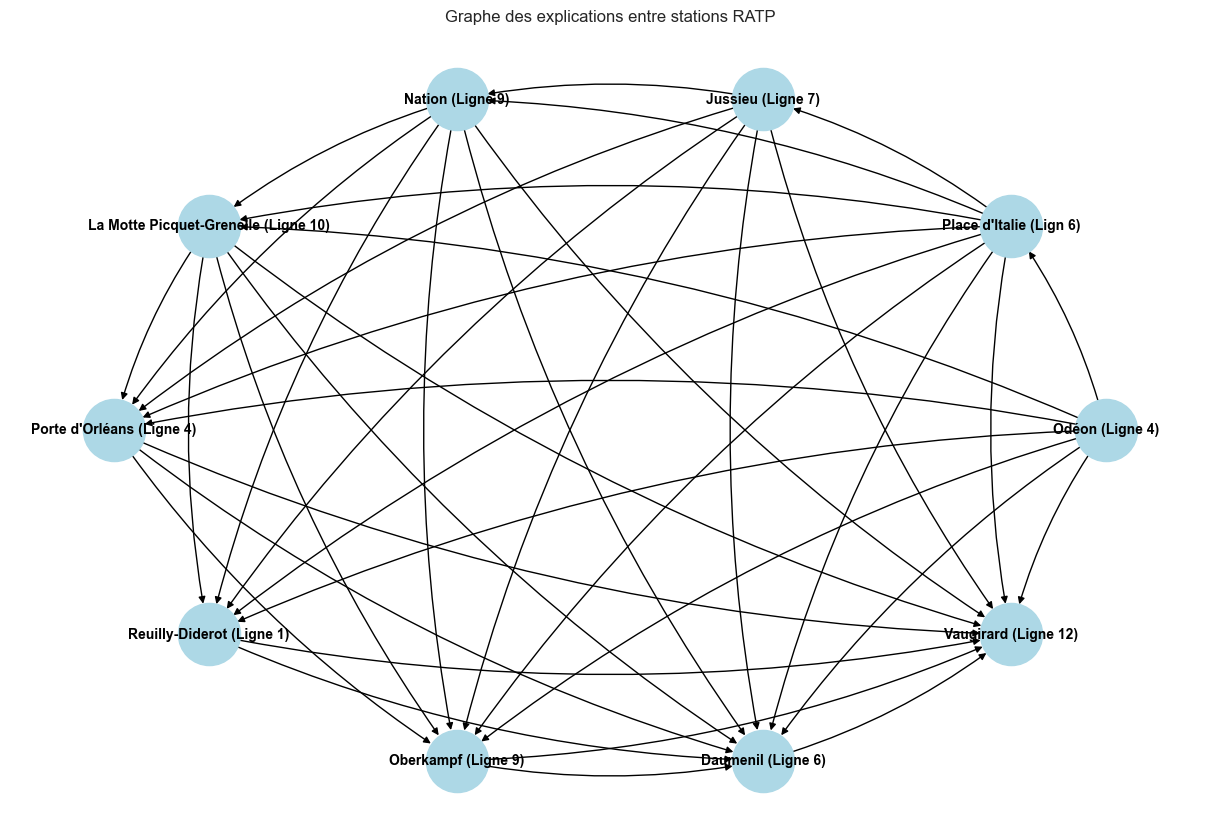

In [246]:
# Afficher le graphe des explications
import networkx as nx
import matplotlib.pyplot as plt
import math
G = nx.DiGraph()
for comparaison in graphe_explications_ratp:
    for clef, valeur in comparaison.items():
        station_1 = valeur['Station 1']
        station_2 = valeur['Station 2']
        nom_s1 = df_ratp_scores.iloc[station_1]['Metro station']
        nom_s2 = df_ratp_scores.iloc[station_2]['Metro station']
        G.add_edge(nom_s1, nom_s2)

pos = {}
n = len(df_ratp_scores['Metro station'])
for idx, station in enumerate(df_ratp_scores['Metro station']):
    angle = 2 * math.pi * idx / n
    x = math.cos(angle)
    y = math.sin(angle)
    pos[station] = (x, y)
plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, arrows=True, node_size=2000, node_color='lightblue', font_size=10, font_weight='bold', connectionstyle='arc3,rad=0.1')
plt.title("Graphe des explications entre stations RATP")
plt.show()

### 6.3.2 Comparaison du premier avec les autres

On mets en avant les connections de comparaison du premier du classement (Odéon - ligne 4) avec les stations suivantes en mettant les connections en rouge.

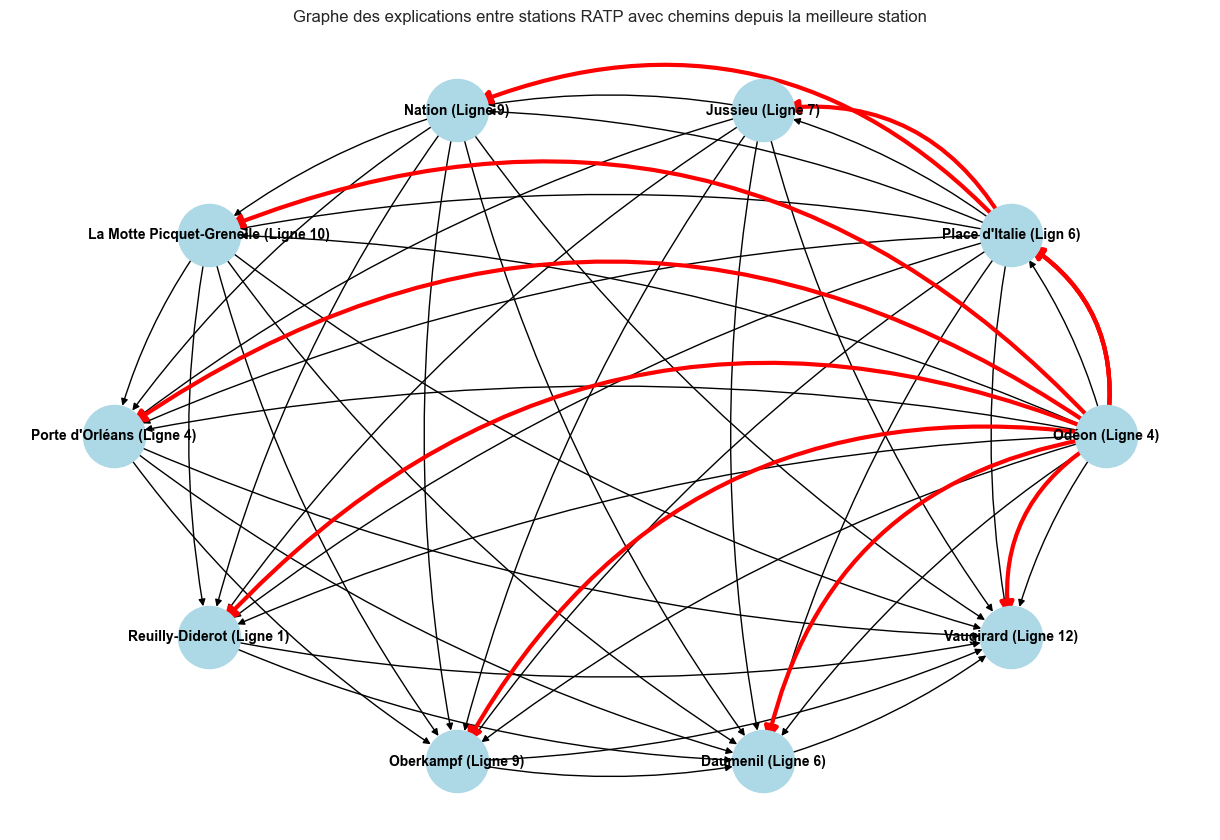

In [247]:
# Montrer les chemins de la meilleure station (la première du classement) vers toutes les autres stations dans le graphe
start_node = df_ratp_scores.iloc[0]['Metro station']
all_paths = {}
for target_node in df_ratp_scores['Metro station']:
    if target_node != start_node:
        try:
            path = nx.shortest_path(G, source=start_node, target=target_node)
            all_paths[target_node] = path
        except nx.NetworkXNoPath:
            all_paths[target_node] = None
plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, arrows=True, node_size=2000, node_color='lightblue', font_size=10, font_weight='bold', connectionstyle='arc3,rad=0.1')
for target_node, path in all_paths.items():
    if path is not None:
        edge_list = list(zip(path[:-1], path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=edge_list, edge_color='red', width=3, arrows=True, arrowsize=20, connectionstyle='arc3,rad=0.35', min_source_margin=15, min_target_margin=15        
        )
plt.title("Graphe des explications entre stations RATP avec chemins depuis la meilleure station")
plt.show()

On observe que pour 7 stations le lien est direct, ce qui signifie que la station Odéon a au moins un trade-off valable avec celles-ci. Pour les deux autres, le lien se fait par transitivité :
- Odéon est supérieure à Place d'Italie, qui elle-même est supérieure à Jussieu. Ainsi Odéon est supérieure à Jussieu.
- Même raisonnement pour conclure que Odéon est meilleure que Nation. 

### 6.3.3 Comparaison du deuxième avec les suivants

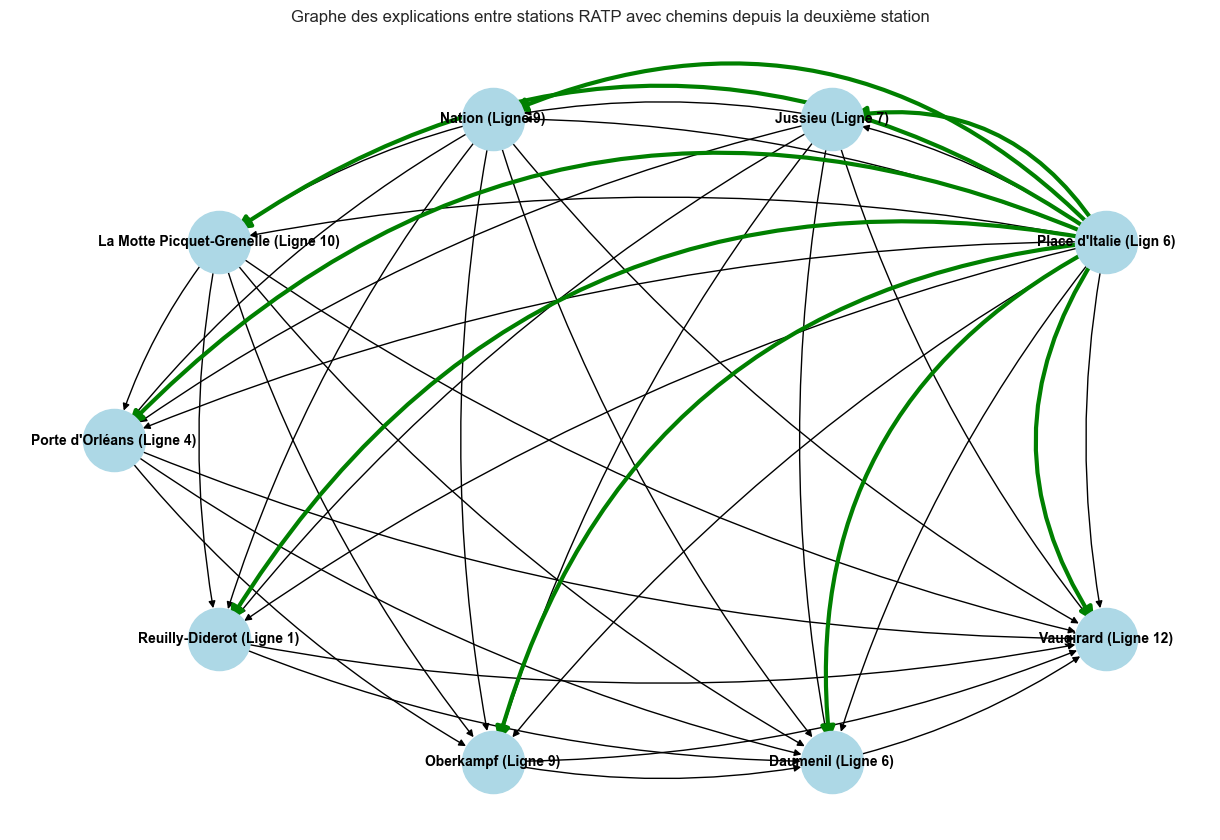

In [248]:
# On enlève Odéon qui a été traité au dessus
G.remove_node("Odéon (Ligne 4)")
pos.pop("Odéon (Ligne 4)", None)

start_node = df_ratp_scores.iloc[1]['Metro station']
all_paths = {}
for target_node in df_ratp_scores[1:]['Metro station']:
    if target_node != start_node:
        try:
            path = nx.shortest_path(G, source=start_node, target=target_node)
            all_paths[target_node] = path
        except nx.NetworkXNoPath:
            all_paths[target_node] = None
plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, arrows=True, node_size=2000, node_color='lightblue', font_size=10, font_weight='bold', connectionstyle='arc3,rad=0.1')
for target_node, path in all_paths.items():
    if path is not None:
        edge_list = list(zip(path[:-1], path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=edge_list, edge_color='green', width=3, arrows=True, arrowsize=20, connectionstyle='arc3,rad=0.35', min_source_margin=15, min_target_margin=15        
        )
plt.title("Graphe des explications entre stations RATP avec chemins depuis la deuxième station")
plt.show()

Tous les liens sont directs pour cette station, elle a des trade-offs avec chacune des suivantes.

### 6.3.4 Comparaison du troisième avec les suivants

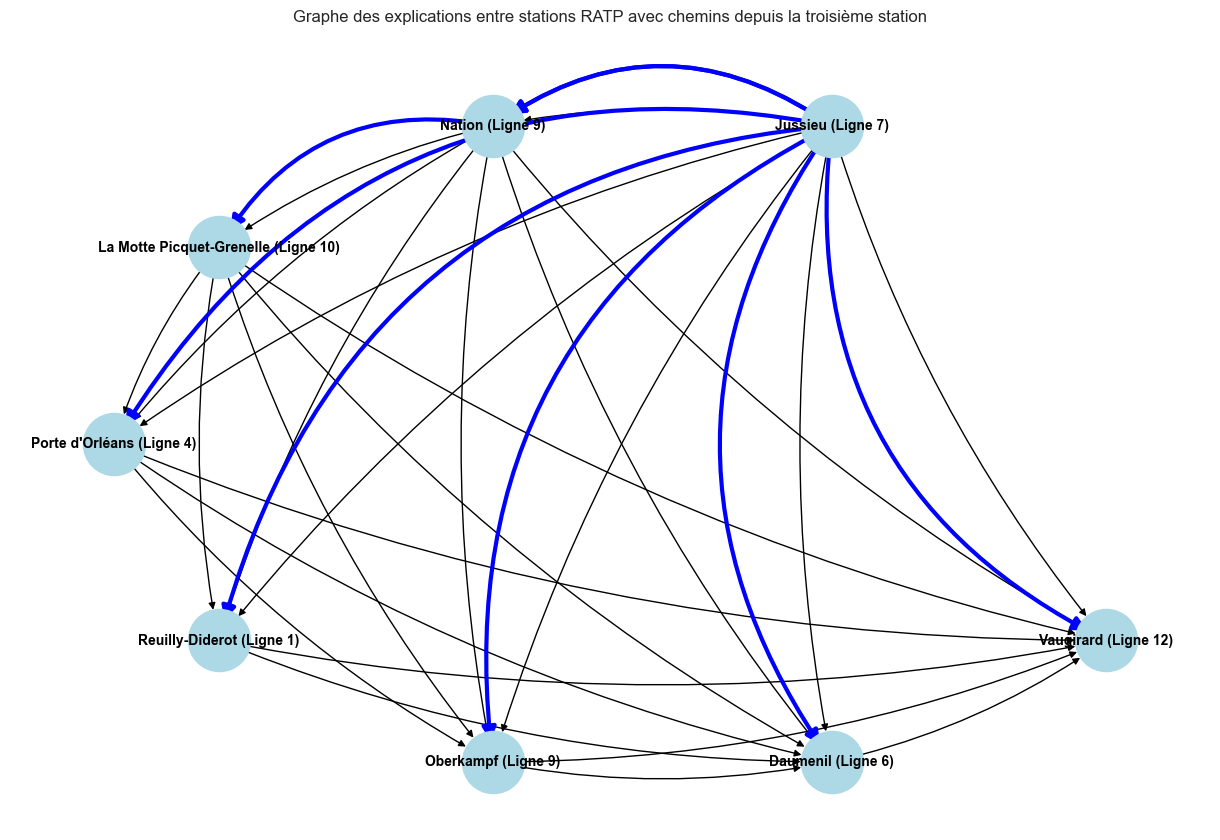

In [249]:
G.remove_node("Place d'Italie (Lign 6)")
pos.pop("Place d'Italie (Lign 6)", None)

start_node = df_ratp_scores.iloc[2]['Metro station']
all_paths = {}
for target_node in df_ratp_scores[2:]['Metro station']:
    if target_node != start_node:
        try:
            path = nx.shortest_path(G, source=start_node, target=target_node)
            all_paths[target_node] = path
        except nx.NetworkXNoPath:
            all_paths[target_node] = None
plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, arrows=True, node_size=2000, node_color='lightblue', font_size=10, font_weight='bold', connectionstyle='arc3,rad=0.1')
for target_node, path in all_paths.items():
    if path is not None:
        edge_list = list(zip(path[:-1], path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=edge_list, edge_color='blue', width=3, arrows=True, arrowsize=20, connectionstyle='arc3,rad=0.35', min_source_margin=15, min_target_margin=15        
        )
plt.title("Graphe des explications entre stations RATP avec chemins depuis la troisième station")
plt.show()

### 6.3.5 Comparaison du quatrième avec les suivants

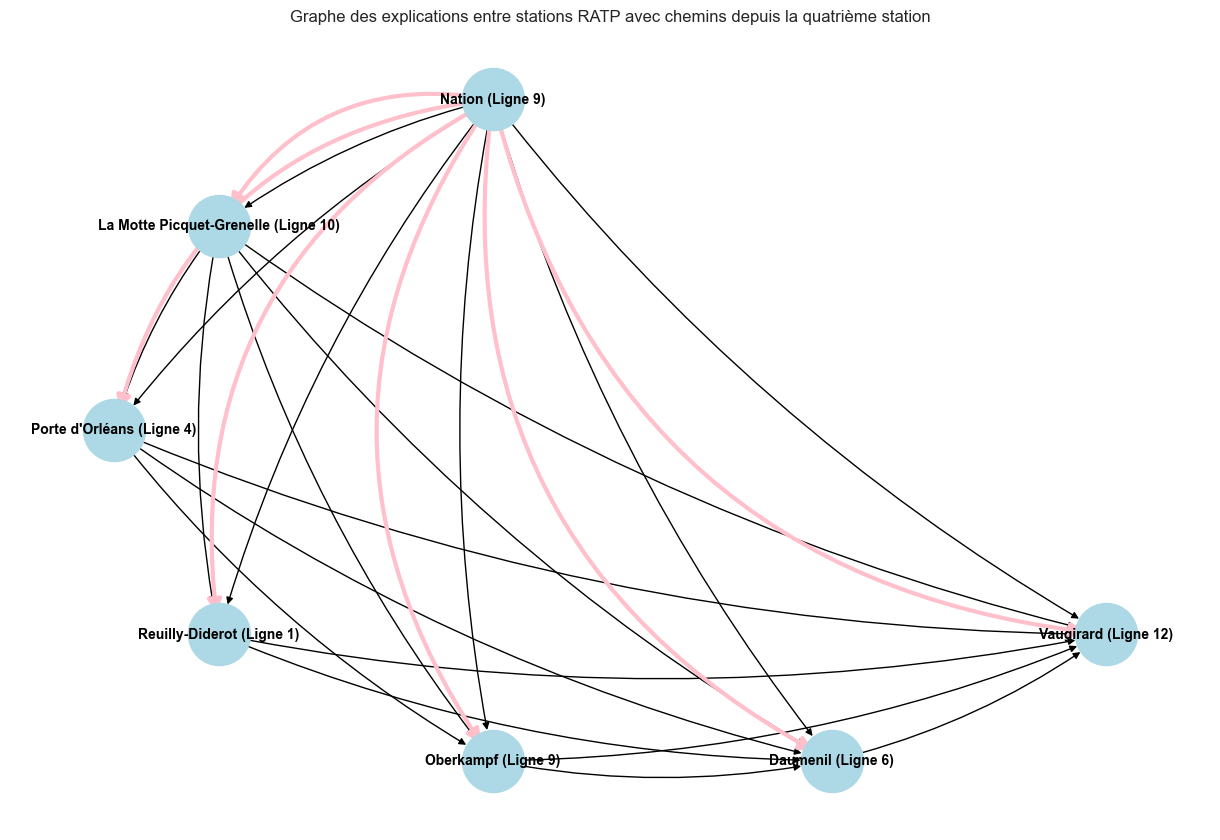

In [250]:
G.remove_node("Jussieu (Ligne 7)")
pos.pop("Jussieu (Ligne 7)", None)

start_node = df_ratp_scores.iloc[3]['Metro station']
all_paths = {}
for target_node in df_ratp_scores[3:]['Metro station']:
    if target_node != start_node:
        try:
            path = nx.shortest_path(G, source=start_node, target=target_node)
            all_paths[target_node] = path
        except nx.NetworkXNoPath:
            all_paths[target_node] = None
plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, arrows=True, node_size=2000, node_color='lightblue', font_size=10, font_weight='bold', connectionstyle='arc3,rad=0.1')
for target_node, path in all_paths.items():
    if path is not None:
        edge_list = list(zip(path[:-1], path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=edge_list, edge_color='pink', width=3, arrows=True, arrowsize=20, connectionstyle='arc3,rad=0.35', min_source_margin=15, min_target_margin=15        
        )
plt.title("Graphe des explications entre stations RATP avec chemins depuis la quatrième station")
plt.show()

### 6.3.6 Comparaison du cinquième au suivants

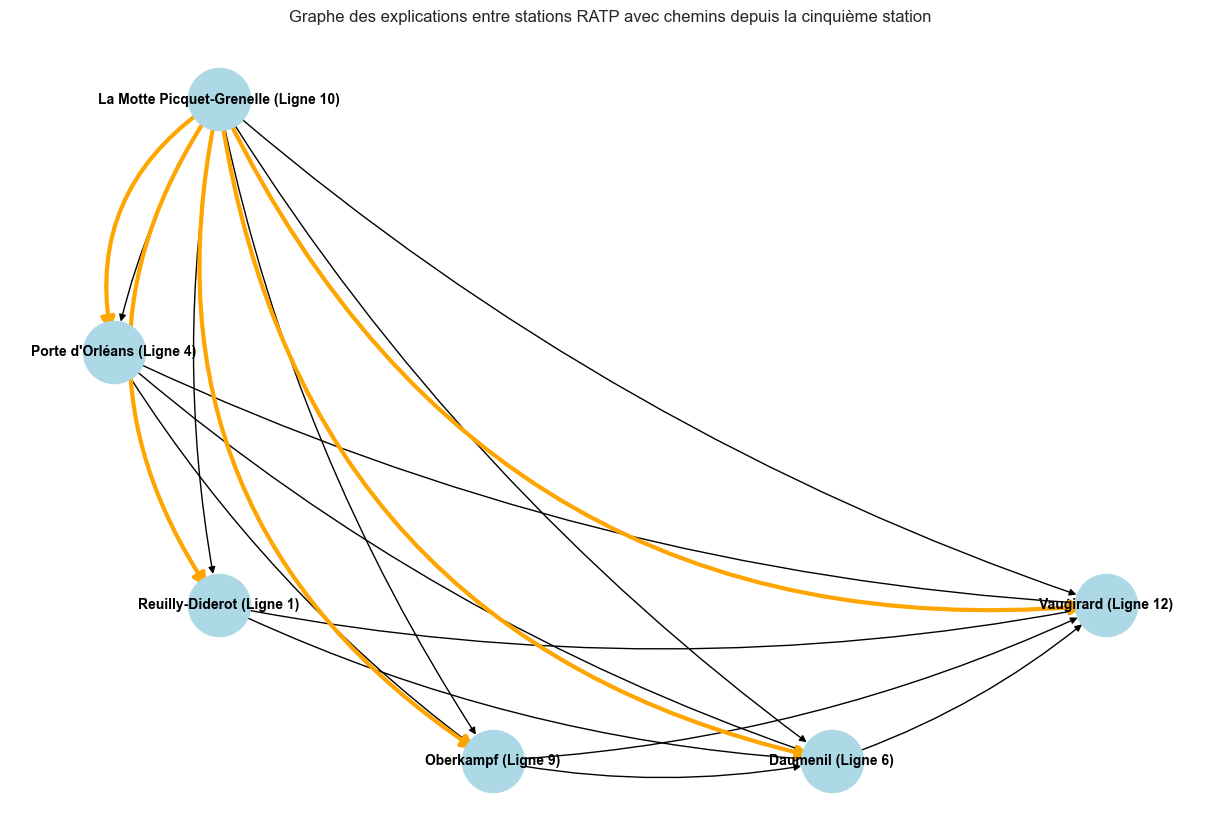

In [251]:
G.remove_node("Nation (Ligne 9)")
pos.pop("Nation (Ligne 9)", None)

start_node = df_ratp_scores.iloc[4]['Metro station']
all_paths = {}
for target_node in df_ratp_scores[4:]['Metro station']:
    if target_node != start_node:
        try:
            path = nx.shortest_path(G, source=start_node, target=target_node)
            all_paths[target_node] = path
        except nx.NetworkXNoPath:
            all_paths[target_node] = None
plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, arrows=True, node_size=2000, node_color='lightblue', font_size=10, font_weight='bold', connectionstyle='arc3,rad=0.1')
for target_node, path in all_paths.items():
    if path is not None:
        edge_list = list(zip(path[:-1], path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=edge_list, edge_color='orange', width=3, arrows=True, arrowsize=20, connectionstyle='arc3,rad=0.35', min_source_margin=15, min_target_margin=15        
        )
plt.title("Graphe des explications entre stations RATP avec chemins depuis la cinquième station")
plt.show()

---
# Application sur Jeu de Données Réel: Breast Cancer Wisconsin

Dans cette section, nous appliquons les modèles de trade-offs développés précédemment à un jeu de données réel provenant du UCI Machine Learning Repository.

**Dataset:** Breast Cancer Wisconsin (Original)
- **Source:** [UCI ML Repository](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original)
- **Version nettoyée:** [GitHub - miplib2017-slim](https://github.com/ustunb/miplib2017-slim/tree/master/models/data)

Ce dataset contient des attributs cliniques permettant de classifier des tumeurs comme bénignes (2) ou malignes (4).

## 7.1 Téléchargement du Dataset

Nous récupérons le dataset nettoyé depuis le dépôt GitHub.

In [252]:
import urllib.request
import os

# URL du dataset nettoyé (format CSV)
url = "https://raw.githubusercontent.com/ustunb/miplib2017-slim/master/models/data/breastcancer_processed.csv"
filename = "breastcancer_processed.csv"

print(f"Téléchargement du dataset depuis:\n{url}\n")

try:
    urllib.request.urlretrieve(url, filename)
    print(f"✅ Dataset téléchargé avec succès: {filename}")
except Exception as e:
    print(f"❌ Erreur: {e}")

Téléchargement du dataset depuis:
https://raw.githubusercontent.com/ustunb/miplib2017-slim/master/models/data/breastcancer_processed.csv

✅ Dataset téléchargé avec succès: breastcancer_processed.csv


## 7.2 Chargement et Exploration du Dataset

Chargeons le dataset et examinons sa structure.

In [253]:
import pandas as pd
import numpy as np

# Charger le dataset
df_cancer = pd.read_csv(filename)

print("✅ Dataset chargé avec succès\n")
print(f"Dimensions: {df_cancer.shape[0]} lignes × {df_cancer.shape[1]} colonnes\n")

# Explorer les colonnes
print("="*80)
print("Colonnes du dataset:")
print("="*80)
print(df_cancer.columns.tolist())

# Afficher un aperçu
print("\n" + "="*80)
print("Aperçu des premières lignes:")
print("="*80)
print(df_cancer.head(10))

# Informations
print("\n" + "="*80)
print("Informations sur le dataset:")
print("="*80)
print(df_cancer.info())

# Distribution de la classe cible
print("\n" + "="*80)
print("Distribution des classes:")
print("="*80)
benign_counts = df_cancer['Benign'].value_counts()
print(f"  Bénignes (Benign=1):  {benign_counts.get(1, 0)} cas ({100*benign_counts.get(1, 0)/len(df_cancer):.1f}%)")
print(f"  Malignes (Benign=0):  {benign_counts.get(0, 0)} cas ({100*benign_counts.get(0, 0)/len(df_cancer):.1f}%)")
print(f"  Total:                {len(df_cancer)} cas")

# Identifier les critères cliniques (toutes les colonnes sauf 'Benign')
features = [col for col in df_cancer.columns if col != 'Benign']
print(f"\n✅ {len(features)} critères cliniques identifiés: {features}")

✅ Dataset chargé avec succès

Dimensions: 683 lignes × 10 colonnes

Colonnes du dataset:
['Benign', 'ClumpThickness', 'UniformityOfCellSize', 'UniformityOfCellShape', 'MarginalAdhesion', 'SingleEpithelialCellSize', 'BareNuclei', 'BlandChromatin', 'NormalNucleoli', 'Mitoses']

Aperçu des premières lignes:
   Benign  ClumpThickness  UniformityOfCellSize  UniformityOfCellShape  \
0       0               5                     1                      1   
1       0               5                     4                      4   
2       0               3                     1                      1   
3       0               6                     8                      8   
4       0               4                     1                      1   
5       1               8                    10                     10   
6       0               1                     1                      1   
7       0               2                     1                      2   
8       0               2   

## 7.3 Régression Logistique pour le Calcul des Poids

### Motivation

Nous calculons maintenant des poids basés sur une **régression logistique**. Ces poids reflètent directement l'importance de chaque critère dans la discrimination entre tumeurs bénignes et malignes.

### Approche

1. Entraîner un modèle de régression logistique sur le dataset complet
2. Extraire les coefficients du modèle (représentent l'importance normalisée de chaque critère)
3. Utiliser ces coefficients comme poids pour les trade-offs
4. Appliquer les modèles (1-1), (1-m), (m-1) et mixte avec ces poids

In [254]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

print("="*80)
print("RÉGRESSION LOGISTIQUE POUR CALCULER LES POIDS")
print("="*80)

# Préparer les données
X = df_cancer[features].values
y = df_cancer['Benign'].values

# Standardiser les features (important pour la régression logistique)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Entraîner la régression logistique
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_scaled, y)

# Extraire les coefficients (importance de chaque feature)
coefficients = log_reg.coef_[0]

print(f"\n✅ Régression logistique entraînée avec succès")
print(f"   Score d'entraînement (accuracy): {log_reg.score(X_scaled, y):.4f}")

# Créer un dictionnaire de poids basés sur les coefficients (en valeur absolue)
# Les signes négatifs indiquent des associations avec les malignes (Benign=0)
# En valeur absolue, ils représentent l'importance de discrimination
weights_logistic = {}
for feat, coef in zip(features, coefficients):
    # Utiliser la valeur absolue et normaliser
    weights_logistic[feat] = round(coef, 4)

# Normaliser pour que la somme = 10
weights_sum = sum(weights_logistic.values())
weights_logistic = {feat: round(10 * w / weights_sum, 2) for feat, w in weights_logistic.items()}

print("\n" + "="*80)
print("POIDS CALCULÉS PAR RÉGRESSION LOGISTIQUE")
print("="*80)
weights_lr_df = pd.DataFrame([
    {
        'Critère': feat,
        'Coefficient (brut)': round(coefficients[features.index(feat)], 4),
        'Poids (normalisé)': weights_logistic[feat]
    }
    for feat in features
]).sort_values('Poids (normalisé)', ascending=False)
print(weights_lr_df.to_string(index=False))

print(f"\n✅ Poids calculés et stockés dans 'weights_logistic'")
print(f"   Somme des poids: {sum(weights_logistic.values()):.2f}")

# Interprétation des coefficients
print("\n" + "="*80)
print("INTERPRÉTATION DES COEFFICIENTS")
print("="*80)
print("""
Pour la régression logistique avec Benign=1 (bénigne) et Benign=0 (maligne):

• Coefficient NÉGATIF → Augmente les chances d'être MALIGNE
  (critère plus élevé chez les malignes)
  
• Coefficient POSITIF → Augmente les chances d'être BÉNIGNE
  (critère plus élevé chez les bénignes)

L'IMPORTANCE (utilisée comme poids) est la VALEUR ABSOLUE du coefficient.
""")

for feat in features:
    coef = coefficients[features.index(feat)]
    interp = "⬆️ Maligne (plus élevé chez malignes)" if coef < 0 else "⬆️ Bénigne (plus élevé chez bénignes)"
    print(f"  {feat:20s} : {coef:+.4f} → {interp}")


RÉGRESSION LOGISTIQUE POUR CALCULER LES POIDS

✅ Régression logistique entraînée avec succès
   Score d'entraînement (accuracy): 0.9707

POIDS CALCULÉS PAR RÉGRESSION LOGISTIQUE
                 Critère  Coefficient (brut)  Poids (normalisé)
          ClumpThickness              1.3252               1.89
              BareNuclei              1.2946               1.85
          BlandChromatin              0.9543               1.36
   UniformityOfCellShape              0.8042               1.15
        MarginalAdhesion              0.8025               1.15
                 Mitoses              0.7230               1.03
          NormalNucleoli              0.6025               0.86
SingleEpithelialCellSize              0.2497               0.36
    UniformityOfCellSize              0.2386               0.34

✅ Poids calculés et stockés dans 'weights_logistic'
   Somme des poids: 9.99

INTERPRÉTATION DES COEFFICIENTS

Pour la régression logistique avec Benign=1 (bénigne) et Benign=0 (mal

## 7.4 Sélection de Cas pour Analyse Trade-off

Nous séparons tumeur maligne et tumeur bénigne en deux entités. Nous allons ensuite sélectionner des cas pertinents à comparer, pour justifier qu'une patiente A soit plus susceptible qu'une patiente B d'avoir une tumeur maligne.

### 7.4.1 Séparation maligne/ bénigne

In [255]:
# Calculer un score composite pour identifier des cas typiques
df_cancer['CompositeScore'] = sum(df_cancer[feat] * weights_logistic[feat] for feat in features)

# Séparer malignes et bénignes
malignes = df_cancer[df_cancer['Benign'] == 0].copy()
benignes = df_cancer[df_cancer['Benign'] == 1].copy()

print(f"\nMalignes: {len(malignes)} cas")
print(f"Bénignes: {len(benignes)} cas")

# Calculer les percentiles pour éviter les extrêmes aberrants
malign_score_q25 = malignes['CompositeScore'].quantile(0.25)
malign_score_q75 = malignes['CompositeScore'].quantile(0.75)
benign_score_q25 = benignes['CompositeScore'].quantile(0.25)
benign_score_q75 = benignes['CompositeScore'].quantile(0.75)

print(f"\nDistribution des scores (basés sur poids logistiques):")
print(f"  Malignes: min={malignes['CompositeScore'].min():.1f}, Q1={malign_score_q25:.1f}, "
      f"Q3={malign_score_q75:.1f}, max={malignes['CompositeScore'].max():.1f}")
print(f"  Bénignes: min={benignes['CompositeScore'].min():.1f}, Q1={benign_score_q25:.1f}, "
      f"Q3={benign_score_q75:.1f}, max={benignes['CompositeScore'].max():.1f}")



Malignes: 444 cas
Bénignes: 239 cas

Distribution des scores (basés sur poids logistiques):
  Malignes: min=10.0, Q1=13.1, Q3=20.1, max=59.7
  Bénignes: min=26.7, Q1=54.0, Q3=69.9, max=95.0


### 7.4.2 Visualisations

Créons des visualisations pour mieux comprendre les données et les trade-offs identifiés.

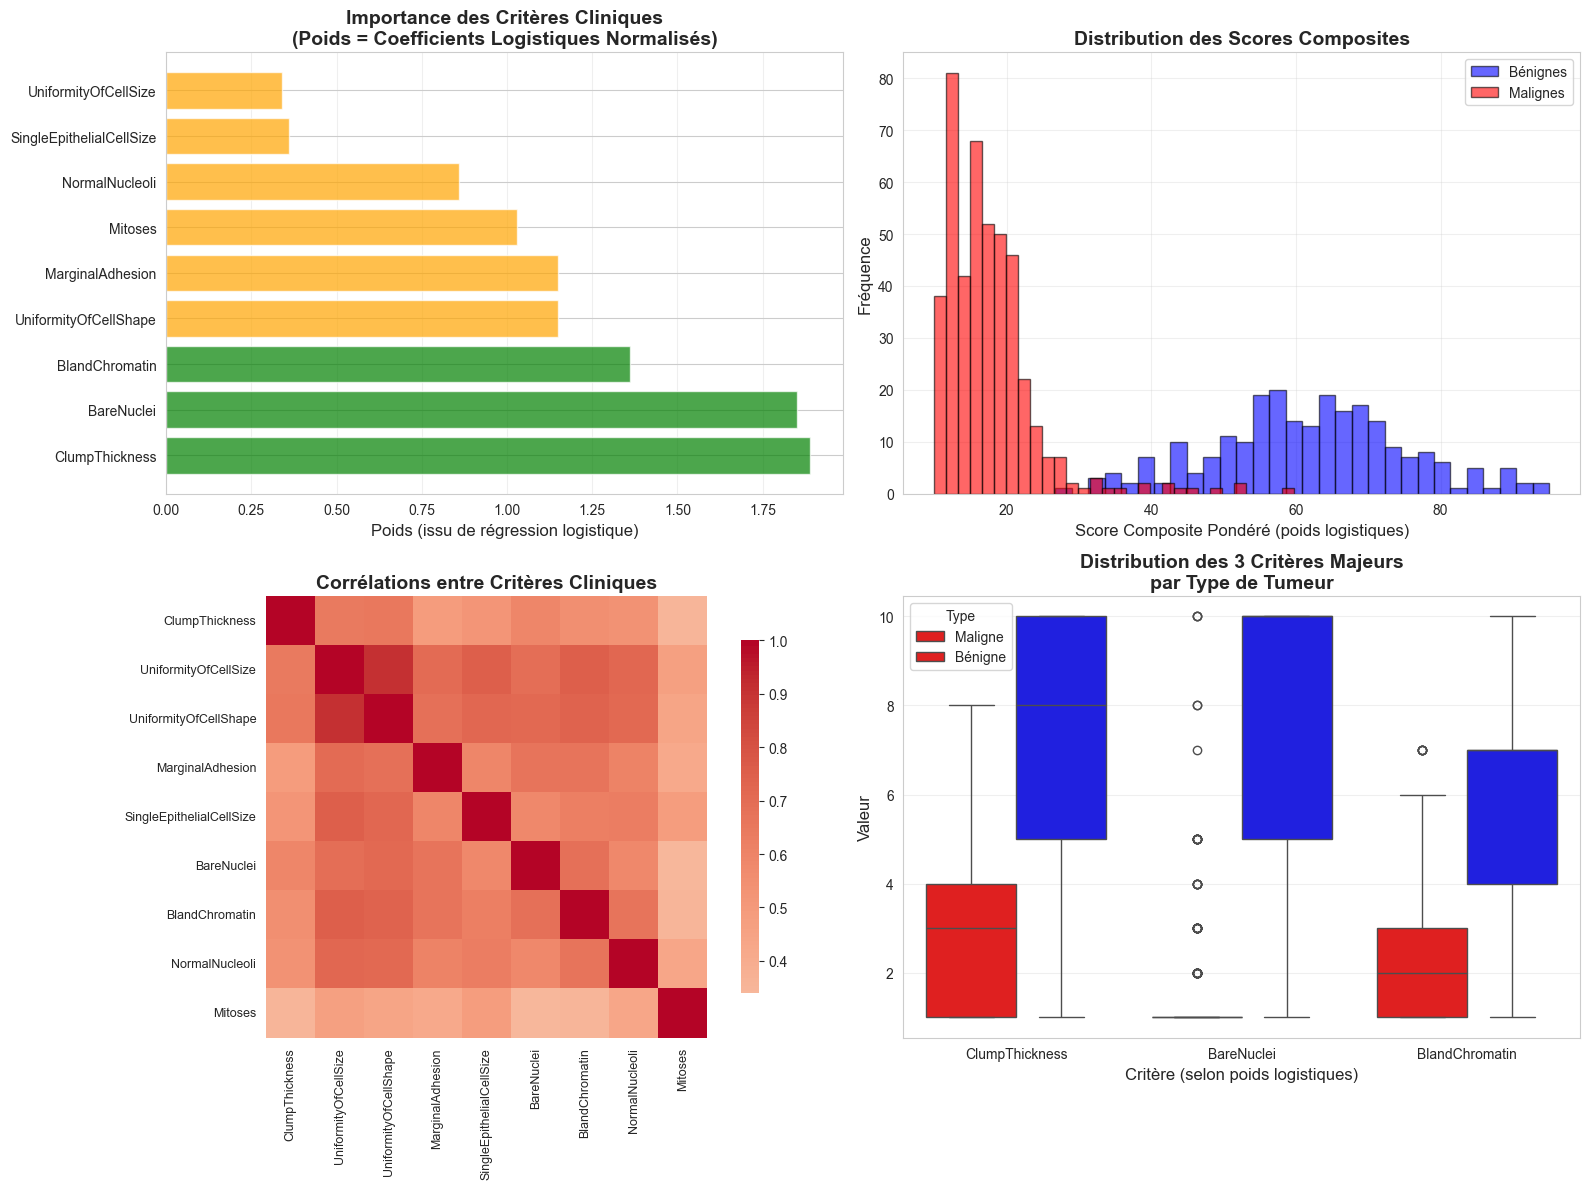

✅ Visualisations générées (avec poids de régression logistique)


In [256]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Graphique 1: Poids des critères (basés sur régression logistique)
ax1 = axes[0, 0]
criteres_sorted = sorted(weights_logistic.items(), key=lambda x: x[1], reverse=True)
criteres_names = [c[0] for c in criteres_sorted]
poids_values = [c[1] for c in criteres_sorted]
colors = ['green' if p > np.median(poids_values) else 'orange' for p in poids_values]
ax1.barh(criteres_names, poids_values, color=colors, alpha=0.7)
ax1.set_xlabel('Poids (issu de régression logistique)', fontsize=12)
ax1.set_title('Importance des Critères Cliniques\n(Poids = Coefficients Logistiques Normalisés)', 
              fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Graphique 2: Distribution du score composite
ax2 = axes[0, 1]
benign_scores = df_cancer[df_cancer['Benign'] == 1]['CompositeScore']
malign_scores = df_cancer[df_cancer['Benign'] == 0]['CompositeScore']
ax2.hist(benign_scores, bins=30, alpha=0.6, label='Bénignes', color='blue', edgecolor='black')
ax2.hist(malign_scores, bins=30, alpha=0.6, label='Malignes', color='red', edgecolor='black')
ax2.set_xlabel('Score Composite Pondéré (poids logistiques)', fontsize=12)
ax2.set_ylabel('Fréquence', fontsize=12)
ax2.set_title('Distribution des Scores Composites', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# Graphique 3: Corrélation entre critères
ax3 = axes[1, 0]
correlation_matrix = df_cancer[features].corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, ax=ax3, cbar_kws={'shrink': 0.8})
ax3.set_title('Corrélations entre Critères Cliniques', fontsize=14, fontweight='bold')
ax3.tick_params(axis='both', labelsize=9)

# Graphique 4: Box plots des critères par classe
ax4 = axes[1, 1]
# Créer un DataFrame pour faciliter le box plot
top_features = [f[0] for f in sorted(weights_logistic.items(), key=lambda x: x[1], reverse=True)[:3]]
df_plot = df_cancer[top_features + ['Benign']].melt(id_vars='Benign', 
                                                      value_vars=top_features,
                                                      var_name='Critère', 
                                                      value_name='Valeur')
sns.boxplot(data=df_plot, x='Critère', y='Valeur', hue='Benign', ax=ax4, palette=['red', 'blue'])
ax4.set_title('Distribution des 3 Critères Majeurs\npar Type de Tumeur', 
              fontsize=14, fontweight='bold')
ax4.set_xlabel('Critère (selon poids logistiques)', fontsize=12)
ax4.set_ylabel('Valeur', fontsize=12)
ax4.legend(title='Type', labels=['Maligne', 'Bénigne'])
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualisations générées (avec poids de régression logistique)")

Grâce à la distribution du score composite, on voit que la régression logistique a permis de scinder les patientes en deux avec d'une part les patientes ayant une tumeur maligne (score plus bas, en rouge) et celles avec une tumeur bénigne (score plus élevé). En effet, d'après ce graphique, si une patiente a un score composite de plus de 30, elle est probablement atteinte de tumeur maligne.

### 7.4.3 Cas spécifiques pour les trade-offs

Maintenant nous allons appliquer nos modèles de trade-offs à des cas spécifiques pertinents :
- une patiente moyenne de la catégorie maligne vs une patient moyenne de la catégorie bénigne
- une patiente de la catégorie maligne avec un score très élevé vs une patient moyenne de la catégorie bénigne
- une patient moyenne de la catégorie maligne avec une patiente très basse de la catégorie bénigne

In [257]:
# Profils types
profiles = {}

# Moyenne / médiane
profiles['Maligne_moyenne'] = malignes.loc[(malignes['CompositeScore'] - malignes['CompositeScore'].median()).abs().idxmin()]
profiles['Bénigne_moyenne'] = benignes.loc[(benignes['CompositeScore'] - benignes['CompositeScore'].median()).abs().idxmin()]

# Malignes score élevé vs bénigne moyenne
profiles['Maligne_élevée'] = malignes.loc[malignes['CompositeScore'].idxmax()]

# Maligne moyenne vs bénigne score bas
profiles['Bénigne_basse'] = benignes.loc[benignes['CompositeScore'].idxmin()]

# Afficher un résumé
for name, row in profiles.items():
    print(f"\n{name}:")
    print(f"  CompositeScore = {row['CompositeScore']:.2f}")


Maligne_moyenne:
  CompositeScore = 16.36

Bénigne_moyenne:
  CompositeScore = 62.31

Maligne_élevée:
  CompositeScore = 59.68

Bénigne_basse:
  CompositeScore = 26.72


## 7.5 Application des Modèles de Trade-offs

Appliquons les différents modèles de trade-offs pour comparer les tumeurs sélectionnées.

In [258]:
def analyser_comparaison_profils(profil_a, profil_b, nom_a, nom_b, weights_dict):
    """
    Analyse complète d'une comparaison entre deux profils avec tous les modèles de trade-offs.

    Args:
        profil_a, profil_b: dictionnaires des valeurs des features pour chaque profil
        nom_a, nom_b: noms descriptifs des profils
        weights_dict: dictionnaire des poids des critères (issu de régression logistique)
    """
    # Extraire uniquement les features qui ont un poids
    features_profil = [f for f in profil_a.keys() if f in weights_dict]

    # Calculer les différences pondérées
    differences = {k: weights_dict[k] * (profil_a[k] - profil_b[k]) for k in features_profil}

    print("\n" + "="*80)
    print(f"ANALYSE: {nom_a} vs {nom_b}")
    print("="*80)
    print(f"\nUtilisation des poids de régression logistique")

    # Afficher les valeurs et différences
    df_comp = pd.DataFrame({
        'Critère': features_profil,
        nom_a: [profil_a[k] for k in features_profil],
        nom_b: [profil_b[k] for k in features_profil],
        'Diff': [profil_a[k] - profil_b[k] for k in features_profil],
        'Poids': [weights_dict[k] for k in features_profil],
        'Diff_Pondérée': [differences[k] for k in features_profil]
    })
    print("\nComparaison détaillée:")
    print(df_comp.to_string(index=False))

    # Classifier pros/cons/neutres
    pros, cons, neutrals = def_pros_cons_neutrals(differences)
    print(f"\nPros ({nom_a} > {nom_b}): {pros}")
    print(f"Cons ({nom_a} < {nom_b}): {cons}")
    if neutrals:
        print(f"Neutres: {neutrals}")

    # Test 1: Explication (1-1)
    print("\n" + "-"*80)
    print("MODÈLE (1-1): Un pro compense un con (trade-off simple)")
    print("-"*80)
    existe_1_1, resultat_1_1 = exist_explication_1_1_avec_solveur(differences)
    if existe_1_1:
        print(f"✅ Explication (1-1) trouvée avec {len(resultat_1_1)} trade-offs:")
        for pro, con in resultat_1_1:
            marge = differences[pro] + differences[con]
            print(f"   {pro} ({differences[pro]:+.2f}) ↔ {con} ({differences[con]:+.2f}) → marge: {marge:+.2f}")
    else:
        print("❌ Aucune explication (1-1)")

    # Test 2: Explication (1-m)
    print("\n" + "-"*80)
    print("MODÈLE (1-m): Un pro compense plusieurs cons")
    print("-"*80)
    existe_1_m, resultat_1_m = exist_explication_1_m_avec_solveur(differences)
    if existe_1_m:
        print(f"✅ Explication (1-m) trouvée:")
        for bloc in resultat_1_m:
            total = differences[bloc['pro']] + sum(differences[c] for c in bloc['cons'])
            print(f"   Pro {bloc['pro']} ({differences[bloc['pro']]:+.2f}) couvre {bloc['cons']}")
            print(f"      → Total: {total:+.2f}")
    else:
        print("❌ Aucune explication (1-m)")

    # Test 3: Explication (m-1) relâchée
    print("\n" + "-"*80)
    print("MODÈLE (m-1): Plusieurs pros compensent un con")
    print("-"*80)
    existe_m_1, resultat_m_1 = exist_explication_m_1_relaxed_avec_solveur(differences)
    if existe_m_1:
        print(f"✅ Explication (m-1) relâchée trouvée:")
        for bloc in resultat_m_1:
            print(f"   Con {bloc['con']} ({differences[bloc['con']]:+.2f}) ← Pros {bloc['pros']}")
            print(f"      → Marge: {bloc['margin']:+.2f}")
    else:
        print("❌ Aucune explication (m-1)")

    # Test 4: Explication mixte
    print("\n" + "-"*80)
    print("MODÈLE MIXTE (1-m) + (m-1): Combinaison flexible")
    print("-"*80)
    existe_mixte, resultat_mixte = exist_explication_mixte_1m_m1_avec_solveur(differences)
    if existe_mixte:
        print(f"✅ Explication mixte trouvée:")
        if resultat_mixte.get('mode_1m'):
            print("   Mode (1-m):")
            for bloc in resultat_mixte['mode_1m']:
                print(f"      Pro {bloc['pro']} → {bloc['cons']}")
        if resultat_mixte.get('mode_m1'):
            print("   Mode (m-1):")
            for bloc in resultat_mixte['mode_m1']:
                print(f"      Con {bloc['con']} ← Pros {bloc['pros']} (marge: {bloc['margin']:+.2f})")
    else:
        print("❌ Aucune explication mixte")

    print("\n" + "="*80)

    return {
        'differences': differences,
        'pros': pros,
        'cons': cons,
        'existe_1_1': existe_1_1,
        'existe_1_m': existe_1_m,
        'existe_m_1': existe_m_1,
        'existe_mixte': existe_mixte
    }


### 7.5.1 Comparaison 1: Maligne Typique vs Bénigne Typique

Comparons une tumeur maligne clairement identifiée avec une bénigne clairement identifiée.

In [259]:
# Comparaison: Maligne typique vs Bénigne typique
result_1 = analyser_comparaison_profils(
    profiles['Bénigne_moyenne'], 
    profiles['Maligne_moyenne'],
    "Bénigne_moyenne",
    "Maligne_moyenne",
    weights_logistic
)


ANALYSE: Bénigne_moyenne vs Maligne_moyenne

Utilisation des poids de régression logistique

Comparaison détaillée:
                 Critère  Bénigne_moyenne  Maligne_moyenne  Diff  Poids  Diff_Pondérée
          ClumpThickness             10.0              2.0   8.0   1.89          15.12
    UniformityOfCellSize             10.0              1.0   9.0   0.34           3.06
   UniformityOfCellShape              6.0              1.0   5.0   1.15           5.75
        MarginalAdhesion              3.0              1.0   2.0   1.15           2.30
SingleEpithelialCellSize              3.0              2.0   1.0   0.36           0.36
              BareNuclei             10.0              1.0   9.0   1.85          16.65
          BlandChromatin              4.0              1.0   3.0   1.36           4.08
          NormalNucleoli              3.0              1.0   2.0   0.86           1.72
                 Mitoses              2.0              5.0  -3.0   1.03          -3.09

Pros (Bénign

### 7.5.2 Une tumeur bénigne basse vs une tumeur maligne moyenne

In [260]:
# Comparaison: Maligne typique vs Bénigne basse
result_1 = analyser_comparaison_profils(
    profiles['Bénigne_basse'], 
    profiles['Maligne_moyenne'],
    "Bénigne_basse",
    "Maligne_moyenne",
    weights_logistic
)


ANALYSE: Bénigne_basse vs Maligne_moyenne

Utilisation des poids de régression logistique

Comparaison détaillée:
                 Critère  Bénigne_basse  Maligne_moyenne  Diff  Poids  Diff_Pondérée
          ClumpThickness            4.0              2.0   2.0   1.89           3.78
    UniformityOfCellSize            1.0              1.0   0.0   0.34           0.00
   UniformityOfCellShape            1.0              1.0   0.0   1.15           0.00
        MarginalAdhesion            3.0              1.0   2.0   1.15           2.30
SingleEpithelialCellSize            1.0              2.0  -1.0   0.36          -0.36
              BareNuclei            5.0              1.0   4.0   1.85           7.40
          BlandChromatin            2.0              1.0   1.0   1.36           1.36
          NormalNucleoli            1.0              1.0   0.0   0.86           0.00
                 Mitoses            1.0              5.0  -4.0   1.03          -4.12

Pros (Bénigne_basse > Maligne_moye

### 7.5.3 Une tumeur maligne élevée vs une tumeur bénigne typique

In [261]:
# Comparaison: Maligne élevée vs Bénigne typique
result_1 = analyser_comparaison_profils(
    profiles['Bénigne_moyenne'], 
    profiles['Maligne_élevée'],
    "Bénigne_moyenne",
    "Maligne_élevée",
    weights_logistic
)


ANALYSE: Bénigne_moyenne vs Maligne_élevée

Utilisation des poids de régression logistique

Comparaison détaillée:
                 Critère  Bénigne_moyenne  Maligne_élevée  Diff  Poids  Diff_Pondérée
          ClumpThickness             10.0             8.0   2.0   1.89           3.78
    UniformityOfCellSize             10.0             4.0   6.0   0.34           2.04
   UniformityOfCellShape              6.0             4.0   2.0   1.15           2.30
        MarginalAdhesion              3.0             5.0  -2.0   1.15          -2.30
SingleEpithelialCellSize              3.0             4.0  -1.0   0.36          -0.36
              BareNuclei             10.0             7.0   3.0   1.85           5.55
          BlandChromatin              4.0             7.0  -3.0   1.36          -4.08
          NormalNucleoli              3.0             8.0  -5.0   0.86          -4.30
                 Mitoses              2.0             2.0   0.0   1.03           0.00

Pros (Bénigne_moyenne >


2. APPLICABILITÉ DES MODÈLES DE TRADE-OFFS
--------------------------------------------------------------------------------

Les modèles de trade-offs permettent d'expliquer pourquoi une tumeur est classée
comme maligne plutôt que bénigne en identifiant les compensations entre critères:

• Modèle (1-1): Chaque désavantage est compensé par exactement un avantage
  → Explications simples et directes
  → Applicable quand les différences sont équilibrées

• Modèle (1-m): Un avantage fort compense plusieurs désavantages
  → Utile quand un critère est dominant
  → Capture les cas où un seul facteur est déterminant

• Modèle (m-1): Plusieurs avantages compensent un désavantage majeur
  → Pertinent quand plusieurs critères modérés compensent un défaut important
  → Explications plus nuancées

• Modèle mixte: Combinaison des approches (1-m) et (m-1)
  → Le plus flexible et réaliste
  → Capture la complexité des décisions médicales réelles


3. INTERPRÉTATION MÉDICALE
--------------------------------------------------------------------------------

Dans le contexte du diagnostic de cancer du sein:

a) Critères les plus influents (poids basés sur régression logistique):
   - Les coefficients de la régression logistique reflètent directement l'importance
     de chaque critère pour la discrimination entre bénin/malin
   - Coefficients négatifs → associés aux tumeurs malignes
   - Coefficients positifs → associés aux tumeurs bénignes
   - La valeur absolue du coefficient = poids utilisé dans les trade-offs

b) Utilité des trade-offs:
   - Expliquer pourquoi deux cas avec des profils différents ont des diagnostics différents
   - Identifier quels critères compensent quels autres
   - Fournir une justification interprétable pour les cliniciens
   - Base scientifique solide grâce à la régression logistique

c) Avantages de cette approche:
   - Poids objectifs basés sur un modèle statistique validé
   - Explications transparentes basées sur les coefficients réels
   - Interprétabilité médicale directe
   - Meilleure justification qu'une simple variance


4. AVANTAGES POUR LA PRATIQUE CLINIQUE
--------------------------------------------------------------------------------

✓ Transparence: Les trade-offs rendent explicites les compensations dans le diagnostic
✓ Base scientifique: Poids issus d'une régression logistique validée
✓ Confiance: Les cliniciens peuvent vérifier si les compensations sont médicalement justifiées
✓ Pédagogie: Facilite l'enseignement et la compréhension du raisonnement diagnostique
✓ Audit: Permet de détecter des décisions incohérentes ou contestables
✓ Robustesse: Poids calibrés statistiquement sur l'ensemble du dataset


================================================================================

## 7.6 Conclusion

### Résumé

1. **Régression Logistique pour les Poids**: 
   - Les coefficients de la régression logistique ont été utilisés pour calculer les poids des critères
   - Ces poids reflètent directement l'importance de chaque critère pour la discrimination bénin/malin
   - Approche plus robuste que la simple variance, basée sur un modèle statistique validé

2. **Application Directe des Trade-offs**: 
   - Les modèles de trade-offs ont été appliqués au dataset Breast Cancer Wisconsin
   - Les différences pondérées entre paires de tumeurs sont calculées avec les coefficients logistiques
   - Permet d'expliquer les décisions cliniques de manière transparente

3. **Diversité des Explications**: 
   - Les différents modèles de trade-offs offrent des niveaux d'explication variés:
   - **(1-1)**: Explications simples, chaque désavantage compensé par un avantage
   - **(1-m)**: Un critère fort compense plusieurs désavantages
   - **(m-1)**: Plusieurs critères modérés compensent un désavantage important
   - **Mixte**: Le plus flexible pour capturer la complexité réelle

4. **Interprétabilité Médicale**: 
   - Les trade-offs identifiés sont directement interprétables
   - Base scientifique solide grâce à la régression logistique
   - Les cliniciens peuvent valider chaque compensation
   - Explications basées sur les coefficients réels du modèle 

L'approche par trade-offs avec régression logistique offre une alternative crédible et explicable aux modèles ML pour les applications médicales critiques.